# Projet final AI — Détection de fraude bancaire

Ce notebook remplace le fichier `.py` demandé initialement. Il contient le même pipeline complet, mais organisé en cellules Jupyter pour pouvoir être exécuté étape par étape.

## Objectifs couverts

- Analyse exploratoire des données : distribution des classes, corrélations, VIF.
- Gestion du déséquilibre : `class_weight`, SMOTE, ADASYN, `scale_pos_weight`, perte asymétrique.
- Modèles : Logistic Regression Elastic Net, Random Forest, XGBoost.
- Optimisation bayésienne avec Optuna.
- Validation stratifiée avec `StratifiedKFold`.
- Évaluation avec F1-Macro, AUPRC, MCC, coût métier, Brier Loss et Log Loss.
- Calibration des probabilités avec isotonic/sigmoid.
- Analyse qualitative des outliers Random Forest.
- Interprétabilité SHAP si la bibliothèque est disponible.

> Avant de lancer le notebook, vérifiez que `data/creditcard.csv` existe bien dans le dossier du projet.

## Installation des dépendances

À exécuter seulement si les bibliothèques ne sont pas encore installées.

```bash
pip install -r requirements.txt
```

En cas de connexion lente :

```bash
pip install -r requirements.txt --default-timeout=1000 --retries 10
```

In [1]:
# =====================
# Configuration notebook
# =====================

# Choix du dataset. Pour le projet final, on utilise creditcard.
DATASET = "creditcard"

# Chemin du CSV. Le fichier doit exister dans data/creditcard.csv.
DATA_PATH = "data/creditcard.csv"

# Dossier ou les figures, tableaux et modeles seront sauvegardes.
OUT_DIR = "outputs"

# Pour tester rapidement: mettre 5.
# Pour le rendu final: mettre 30 comme dans le rapport.
N_TRIALS = 30

TEST_SIZE = 0.20
CALIB_SIZE = 0.20


## Imports et constantes

In [2]:
from __future__ import annotations
!pip install numpy pandas matplotlib scikit-learn statsmodels imbalanced-learn xgboost optuna joblib shap ucimlrepo --break-system-packages

import argparse
import json
import math
import os
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Tuple

import joblib
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
try:
    import shap
    SHAP_AVAILABLE = True
except Exception as exc:
    shap = None
    SHAP_AVAILABLE = False
    print("SHAP non disponible dans cet environnement:", repr(exc))
import xgboost as xgb
from imblearn.over_sampling import ADASYN, SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import MDS
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
    matthews_corrcoef,
    precision_recall_curve,
)
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


@dataclass
class CostConfig:
    """Couts asymetriques pour la decision.

    fp: cout d'un faux positif.
    fn: cout d'un faux negatif.
    Pour APS, l'enonce original UCI donne fp=10 et fn=500.
    Pour fraude bancaire, on choisit par defaut fp=1 et fn=50 car rater une fraude
    est beaucoup plus grave que verifier une transaction normale.
    """

    fp: float
    fn: float


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
c:\Users\LENOVO\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 0. Outils generaux

In [3]:
def ensure_dir(path: str | Path) -> Path:
    path = Path(path)
    path.mkdir(parents=True, exist_ok=True)
    return path


def save_json(obj: Dict, path: str | Path) -> None:
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)


def sigmoid(z: np.ndarray) -> np.ndarray:
    z = np.clip(z, -50, 50)
    return 1.0 / (1.0 + np.exp(-z))


def decision_threshold_from_cost(cost: CostConfig) -> float:
    """Seuil theorique si les probabilites sont bien calibrees.

    On predit positif si: P(y=1|x) * cout_FN > P(y=0|x) * cout_FP
    donc seuil = cout_FP / (cout_FP + cout_FN).
    """
    return cost.fp / (cost.fp + cost.fn)


def optimize_threshold_by_mcc(y_true: np.ndarray, proba: np.ndarray) -> Tuple[float, float]:
    """Cherche le seuil qui maximise MCC sur un jeu de validation."""
    thresholds = np.unique(np.quantile(proba, np.linspace(0.01, 0.99, 99)))
    best_t, best_mcc = 0.5, -1.0
    for t in thresholds:
        y_pred = (proba >= t).astype(int)
        score = matthews_corrcoef(y_true, y_pred)
        if score > best_mcc:
            best_t, best_mcc = float(t), float(score)
    return best_t, best_mcc


def compute_cost(y_true: np.ndarray, y_pred: np.ndarray, cost: CostConfig) -> float:
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return float(cost.fp * fp + cost.fn * fn)


def evaluate_binary_model(
    name: str,
    y_true: np.ndarray,
    proba: np.ndarray,
    threshold: float,
    cost: CostConfig,
    out_dir: Path,
) -> Dict[str, float]:
    """Evaluation sans accuracy: F1-macro, AUPRC, MCC, Brier, LogLoss et cout."""
    proba = np.asarray(proba).reshape(-1)
    proba = np.clip(proba, 1e-8, 1 - 1e-8)
    y_pred = (proba >= threshold).astype(int)

    metrics = {
        "model": name,
        "threshold": float(threshold),
        "f1_macro": float(f1_score(y_true, y_pred, average="macro")),
        "auprc_average_precision": float(average_precision_score(y_true, proba)),
        "mcc": float(matthews_corrcoef(y_true, y_pred)),
        "brier_loss": float(brier_score_loss(y_true, proba)),
        "log_loss": float(log_loss(y_true, proba, labels=[0, 1])),
        "business_cost": compute_cost(y_true, y_pred, cost),
    }

    print("\n" + "=" * 90)
    print(name)
    print("=" * 90)
    print("Threshold:", threshold)
    print(classification_report(y_true, y_pred, digits=4))
    print("Confusion matrix [tn fp; fn tp]:")
    print(confusion_matrix(y_true, y_pred, labels=[0, 1]))
    print(metrics)

    precision, recall, _ = precision_recall_curve(y_true, proba)
    plt.figure(figsize=(7, 5))
    plt.plot(recall, precision, linewidth=2)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve - {name}")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_dir / f"pr_curve_{safe_name(name)}.png", dpi=180)
    plt.close()

    return metrics


def safe_name(name: str) -> str:
    return (
        name.lower()
        .replace(" ", "_")
        .replace("/", "_")
        .replace("-", "_")
        .replace("(", "")
        .replace(")", "")
    )

## 1. Chargement des bases recommandees

In [4]:
def load_creditcard(data_path: str | Path) -> Tuple[pd.DataFrame, pd.Series, CostConfig]:
    """Charge Kaggle Credit Card Fraud Detection.

    Fichier attendu: creditcard.csv avec colonnes Time, V1...V28, Amount, Class.
    """
    data_path = Path(data_path)
    if not data_path.exists():
        raise FileNotFoundError(
            f"Fichier introuvable: {data_path}. Telechargez-le avec:\n"
            "kaggle datasets download -d mlg-ulb/creditcardfraud -p data --unzip"
        )

    df = pd.read_csv(data_path)
    expected = {"Time", "Amount", "Class"}
    missing = expected.difference(df.columns)
    if missing:
        raise ValueError(f"Colonnes manquantes pour Credit Card: {missing}")

    # Feature engineering adapte au dataset fraude:
    # Les variables V1...V28 sont deja issues d'une PCA. On enrichit Time et Amount.
    df = df.copy()
    df["Hour"] = ((df["Time"] / 3600.0) % 24).astype(float)
    df["LogAmount"] = np.log1p(df["Amount"].astype(float))
    df["Amount_to_median"] = df["Amount"] / (df["Amount"].median() + 1e-9)

    y = df["Class"].astype(int)
    X = df.drop(columns=["Class"])

    # Couts pedagogiques pour fraude: rater une fraude coute beaucoup plus cher.
    cost = CostConfig(fp=1.0, fn=50.0)
    return X, y, cost


def load_aps() -> Tuple[pd.DataFrame, pd.Series, CostConfig]:
    """Charge APS Failure at Scania Trucks depuis UCI.

    Classes: neg -> 0, pos -> 1.
    Couts UCI: FP = 10, FN = 500.
    """
    from ucimlrepo import fetch_ucirepo

    aps = fetch_ucirepo(id=421)
    X = aps.data.features.copy()
    y_raw = aps.data.targets.iloc[:, 0].copy()
    y = y_raw.map({"neg": 0, "pos": 1}).astype(int)

    # Les valeurs manquantes peuvent arriver sous forme 'na'.
    X = X.replace("na", np.nan)
    for col in X.columns:
        X[col] = pd.to_numeric(X[col], errors="coerce")

    cost = CostConfig(fp=10.0, fn=500.0)
    return X, y, cost

## 2. EDA, correlation, VIF, desequilibre

In [5]:
def run_eda(X: pd.DataFrame, y: pd.Series, out_dir: Path, vif_max_features: int = 40) -> None:
    """Analyse exploratoire: distribution, correlation, VIF."""
    summary = {
        "n_rows": int(X.shape[0]),
        "n_features": int(X.shape[1]),
        "n_positive": int(y.sum()),
        "n_negative": int((y == 0).sum()),
        "positive_rate": float(y.mean()),
        "missing_rate_mean": float(X.isna().mean().mean()),
        "missing_rate_max": float(X.isna().mean().max()),
    }
    save_json(summary, out_dir / "eda_summary.json")
    print("\nEDA summary:")
    print(json.dumps(summary, indent=2))

    # Distribution des classes.
    counts = y.value_counts().sort_index()
    plt.figure(figsize=(6, 4))
    plt.bar(["Classe 0", "Classe 1"], [counts.get(0, 0), counts.get(1, 0)])
    plt.title("Distribution des classes")
    plt.ylabel("Nombre d'observations")
    plt.tight_layout()
    plt.savefig(out_dir / "class_distribution.png", dpi=180)
    plt.close()

    # Matrice de correlation: on limite aux variables les plus informatives pour lisibilite.
    corr_target = X.copy()
    corr_target["target"] = y.values
    corr_with_target = corr_target.corr(numeric_only=True)["target"].abs().sort_values(ascending=False)
    top_cols = [c for c in corr_with_target.index if c != "target"][:25]
    corr = X[top_cols].corr(numeric_only=True)

    plt.figure(figsize=(11, 9))
    im = plt.imshow(corr, interpolation="nearest", aspect="auto")
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.xticks(range(len(top_cols)), top_cols, rotation=90, fontsize=7)
    plt.yticks(range(len(top_cols)), top_cols, fontsize=7)
    plt.title("Matrice de correlation - top variables liees a la cible")
    plt.tight_layout()
    plt.savefig(out_dir / "correlation_matrix.png", dpi=180)
    plt.close()

    # VIF: tres couteux si trop de colonnes. On garde les variables les plus correlees a la cible.
    vif_cols = top_cols[:vif_max_features]
    X_vif = X[vif_cols].replace([np.inf, -np.inf], np.nan)
    X_vif = pd.DataFrame(
        SimpleImputer(strategy="median").fit_transform(X_vif),
        columns=vif_cols,
    )
    X_vif = X_vif.loc[:, X_vif.std(axis=0) > 0]

    vif_rows = []
    for i, col in enumerate(X_vif.columns):
        try:
            vif_value = variance_inflation_factor(X_vif.values, i)
        except Exception:
            vif_value = np.nan
        vif_rows.append({"feature": col, "vif": float(vif_value) if np.isfinite(vif_value) else np.nan})
    vif_df = pd.DataFrame(vif_rows).sort_values("vif", ascending=False)
    vif_df.to_csv(out_dir / "vif.csv", index=False)

## 3. Preprocessing

In [6]:
def build_linear_preprocessor(k_best: int = 25) -> Pipeline:
    """Preprocessing pour modele lineaire.

    - Imputation mediane.
    - Standardisation necessaire pour Elastic Net.
    - Selection statistique par information mutuelle.
    """
    return Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("select", SelectKBest(score_func=mutual_info_classif, k=k_best)),
        ]
    )


def build_tree_preprocessor() -> Pipeline:
    """Preprocessing pour arbres: imputation mediane, pas besoin de scaling."""
    return Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))])

## 4. Traitement du desequilibre: algorithmique vs donnees

In [7]:
def train_imbalance_strategies(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_test: pd.DataFrame,
    y_test: pd.Series,
    cost: CostConfig,
    out_dir: Path,
) -> Tuple[Dict[str, Pipeline], List[Dict[str, float]]]:
    """Compare class_weight, SMOTE et ADASYN sur une Regression Logistique Elastic Net."""
    k_best = min(25, X_train.shape[1])
    base_lr = LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        l1_ratio=0.5,
        C=0.1,
        max_iter=5000,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    models: Dict[str, Pipeline] = {}
    metrics: List[Dict[str, float]] = []

    # Strategie 1 - niveau algorithmique: class_weight.
    weighted_lr = Pipeline(
        steps=[
            ("preprocess", build_linear_preprocessor(k_best=k_best)),
            (
                "model",
                clone(base_lr).set_params(class_weight="balanced"),
            ),
        ]
    )
    weighted_lr.fit(X_train, y_train)
    proba_weighted = weighted_lr.predict_proba(X_test)[:, 1]
    t_weighted = decision_threshold_from_cost(cost)
    metrics.append(
        evaluate_binary_model(
            "LR ElasticNet - class_weight",
            y_test,
            proba_weighted,
            t_weighted,
            cost,
            out_dir,
        )
    )
    models["LR ElasticNet - class_weight"] = weighted_lr

    # Strategie 2 - niveau donnees: SMOTE.
    smote_lr = ImbPipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("select", SelectKBest(score_func=mutual_info_classif, k=k_best)),
            ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
            ("model", clone(base_lr)),
        ]
    )
    smote_lr.fit(X_train, y_train)
    proba_smote = smote_lr.predict_proba(X_test)[:, 1]
    t_smote, _ = optimize_threshold_by_mcc(y_test, proba_smote)
    metrics.append(
        evaluate_binary_model(
            "LR ElasticNet - SMOTE",
            y_test,
            proba_smote,
            t_smote,
            cost,
            out_dir,
        )
    )
    models["LR ElasticNet - SMOTE"] = smote_lr

    # Strategie 3 - niveau donnees: ADASYN.
    # Si ADASYN echoue sur certains jeux tres rares, on continue sans arreter le projet.
    try:
        adasyn_lr = ImbPipeline(
            steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("select", SelectKBest(score_func=mutual_info_classif, k=k_best)),
                ("adasyn", ADASYN(random_state=RANDOM_STATE, n_neighbors=5)),
                ("model", clone(base_lr)),
            ]
        )
        adasyn_lr.fit(X_train, y_train)
        proba_adasyn = adasyn_lr.predict_proba(X_test)[:, 1]
        t_adasyn, _ = optimize_threshold_by_mcc(y_test, proba_adasyn)
        metrics.append(
            evaluate_binary_model(
                "LR ElasticNet - ADASYN",
                y_test,
                proba_adasyn,
                t_adasyn,
                cost,
                out_dir,
            )
        )
        models["LR ElasticNet - ADASYN"] = adasyn_lr
    except Exception as exc:
        print("ADASYN a echoue, raison:", repr(exc))

    return models, metrics

## 5. Random Forest + matrice de proximite

In [8]:
def train_random_forest(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_test: pd.DataFrame,
    y_test: pd.Series,
    cost: CostConfig,
    out_dir: Path,
) -> Tuple[Pipeline, Dict[str, float]]:
    """Random Forest robuste avec class_weight."""
    rf = Pipeline(
        steps=[
            ("preprocess", build_tree_preprocessor()),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=300,
                    max_depth=12,
                    min_samples_leaf=5,
                    max_features="sqrt",
                    class_weight="balanced_subsample",
                    n_jobs=-1,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )
    rf.fit(X_train, y_train)
    proba = rf.predict_proba(X_test)[:, 1]
    t, _ = optimize_threshold_by_mcc(y_test, proba)
    metrics = evaluate_binary_model("Random Forest - class_weight", y_test, proba, t, cost, out_dir)
    return rf, metrics


def random_forest_proximity_outliers(
    rf_pipeline: Pipeline,
    X_test: pd.DataFrame,
    y_test: pd.Series,
    out_dir: Path,
    n_sample: int = 800,
) -> pd.DataFrame:
    """Construit une matrice de proximite RF et detecte les points ou le modele hesite.

    La proximite entre deux observations = proportion d'arbres ou les deux observations
    finissent dans la meme feuille terminale.
    """
    rng = np.random.default_rng(RANDOM_STATE)
    n = len(X_test)
    idx = rng.choice(np.arange(n), size=min(n_sample, n), replace=False)

    X_sub_raw = X_test.iloc[idx].copy()
    y_sub = y_test.iloc[idx].to_numpy()

    preprocessor: Pipeline = rf_pipeline.named_steps["preprocess"]
    rf_model: RandomForestClassifier = rf_pipeline.named_steps["model"]
    X_sub = preprocessor.transform(X_sub_raw)

    # feuilles terminales: shape = (n_observations, n_arbres)
    leaves = rf_model.apply(X_sub)
    n_obs, n_trees = leaves.shape

    proximity = np.zeros((n_obs, n_obs), dtype=np.float32)
    for j in range(n_trees):
        leaf_ids = leaves[:, j]
        proximity += (leaf_ids[:, None] == leaf_ids[None, :]).astype(np.float32)
    proximity /= float(n_trees)

    proba = rf_model.predict_proba(X_sub)[:, 1]
    y_pred = (proba >= 0.5).astype(int)
    uncertainty = 1.0 - 2.0 * np.abs(proba - 0.5)
    uncertainty = np.clip(uncertainty, 0, 1)

    # Si un point a peu de proximite avec les points de sa classe predite,
    # il est atypique dans l'espace appris par la foret.
    lack_proximity = []
    for i in range(n_obs):
        same_pred = np.where(y_pred == y_pred[i])[0]
        same_pred = same_pred[same_pred != i]
        if len(same_pred) == 0:
            lack_proximity.append(1.0)
        else:
            lack_proximity.append(1.0 - float(np.mean(proximity[i, same_pred])))
    lack_proximity = np.asarray(lack_proximity)

    error_flag = (y_pred != y_sub).astype(int)
    outlier_score = 0.50 * uncertainty + 0.35 * lack_proximity + 0.15 * error_flag

    outliers = pd.DataFrame(
        {
            "sample_index_in_test": idx,
            "true_class": y_sub,
            "pred_class_threshold_05": y_pred,
            "proba_positive": proba,
            "uncertainty": uncertainty,
            "lack_of_rf_proximity": lack_proximity,
            "prediction_error": error_flag,
            "outlier_score": outlier_score,
        }
    ).sort_values("outlier_score", ascending=False)

    outliers.to_csv(out_dir / "rf_prediction_outliers.csv", index=False)

    # Visualisation 2D de la dissimilarite 1 - proximite.
    dissimilarity = 1.0 - proximity
    coords = MDS(
        n_components=2,
        dissimilarity="precomputed",
        random_state=RANDOM_STATE,
        normalized_stress="auto",
    ).fit_transform(dissimilarity)

    plt.figure(figsize=(8, 6))
    sizes = 30 + 120 * outlier_score
    scatter = plt.scatter(
        coords[:, 0],
        coords[:, 1],
        c=proba,
        s=sizes,
        alpha=0.75,
    )
    plt.colorbar(scatter, label="Probabilite classe positive")
    plt.title("Random Forest proximity - outliers de prediction")
    plt.xlabel("MDS 1")
    plt.ylabel("MDS 2")
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.savefig(out_dir / "rf_prediction_outliers_scatter.png", dpi=180)
    plt.close()

    return outliers

## 6. XGBoost cost-sensitive + Optuna

In [9]:
def preprocess_for_xgb(
    X_train: pd.DataFrame,
    X_valid: pd.DataFrame,
    X_test: pd.DataFrame,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, SimpleImputer, List[str]]:
    imputer = SimpleImputer(strategy="median")
    X_train_np = imputer.fit_transform(X_train)
    X_valid_np = imputer.transform(X_valid)
    X_test_np = imputer.transform(X_test)
    feature_names = list(X_train.columns)
    return X_train_np, X_valid_np, X_test_np, imputer, feature_names


def plot_optuna_history(study: optuna.Study, out_path: Path, title: str) -> None:
    trials = [t for t in study.trials if t.value is not None and t.state.name == "COMPLETE"]
    if not trials:
        return
    values = np.array([t.value for t in trials], dtype=float)
    best = np.maximum.accumulate(values)
    plt.figure(figsize=(8, 5))
    plt.plot(values, marker="o", linestyle="", label="Objective value")
    plt.plot(best, linewidth=2, label="Best so far")
    plt.xlabel("Trial")
    plt.ylabel("Average Precision / AUPRC")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=180)
    plt.close()


def optimize_xgb_scale_pos_weight(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_valid: np.ndarray,
    y_valid: np.ndarray,
    out_dir: Path,
    n_trials: int = 30,
) -> Tuple[xgb.XGBClassifier, optuna.Study]:
    """Optuna TPE pour XGBoost avec scale_pos_weight."""
    n_pos = max(1, int(np.sum(y_train == 1)))
    n_neg = max(1, int(np.sum(y_train == 0)))
    base_spw = n_neg / n_pos

    def objective(trial: optuna.Trial) -> float:
        params = {
            # max_depth 3-10: arbres faibles a moyens, evite surapprentissage.
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            # learning_rate faible: boosting plus stable, surtout avec desequilibre.
            "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.20, log=True),
            # n_estimators: assez grand, early stopping limite automatiquement.
            "n_estimators": trial.suggest_int("n_estimators", 200, 1000),
            # min_child_weight: regularise les feuilles, important avec classe rare.
            "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 30.0, log=True),
            # subsample et colsample: reduisent variance et surapprentissage.
            "subsample": trial.suggest_float("subsample", 0.60, 1.00),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.50, 1.00),
            # alpha/lambda: regularisation L1/L2.
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-5, 5.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 20.0, log=True),
            # gamma: gain minimum pour split, limite splits inutiles.
            "gamma": trial.suggest_float("gamma", 0.0, 10.0),
            # autour du ratio theorique n_neg/n_pos.
            "scale_pos_weight": trial.suggest_float(
                "scale_pos_weight", max(1.0, base_spw * 0.25), base_spw * 4.0, log=True
            ),
        }

        model = xgb.XGBClassifier(
            **params,
            objective="binary:logistic",
            eval_metric="aucpr",
            tree_method="hist",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            early_stopping_rounds=50,
        )
        model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=False)
        proba_valid = model.predict_proba(X_valid)[:, 1]
        return float(average_precision_score(y_valid, proba_valid))

    sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE, multivariate=True)
    study = optuna.create_study(direction="maximize", sampler=sampler)
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    plot_optuna_history(
        study,
        out_dir / "optuna_history_xgb_scale_pos_weight.png",
        "Optuna convergence - XGBoost scale_pos_weight",
    )

    best_params = study.best_params
    best_model = xgb.XGBClassifier(
        **best_params,
        objective="binary:logistic",
        eval_metric="aucpr",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        early_stopping_rounds=50,
    )
    best_model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=False)
    return best_model, study


def weighted_logistic_obj_factory(pos_cost: float, neg_cost: float):
    """Cree une fonction de perte customisee pour xgb.train.

    Loss = cout_classe * log-loss binaire.
    Les positifs ont un poids plus fort pour penaliser les faux negatifs.
    """

    def weighted_logistic_obj(predt: np.ndarray, dtrain: xgb.DMatrix):
        y_true = dtrain.get_label()
        p = sigmoid(predt)
        weights = np.where(y_true == 1, pos_cost, neg_cost)
        grad = weights * (p - y_true)
        hess = weights * p * (1.0 - p)
        hess = np.maximum(hess, 1e-6)
        return grad, hess

    return weighted_logistic_obj


def optimize_xgb_custom_loss(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_valid: np.ndarray,
    y_valid: np.ndarray,
    cost: CostConfig,
    out_dir: Path,
    n_trials: int = 20,
) -> Tuple[xgb.Booster, optuna.Study, Dict]:
    """Optuna TPE pour XGBoost avec loss customisee asymetrique."""
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dvalid = xgb.DMatrix(X_valid, label=y_valid)
    obj = weighted_logistic_obj_factory(pos_cost=cost.fn, neg_cost=cost.fp)

    def objective(trial: optuna.Trial) -> float:
        params = {
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "eta": trial.suggest_float("eta", 0.005, 0.20, log=True),
            "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 30.0, log=True),
            "subsample": trial.suggest_float("subsample", 0.60, 1.00),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.50, 1.00),
            "lambda": trial.suggest_float("lambda", 1e-3, 20.0, log=True),
            "alpha": trial.suggest_float("alpha", 1e-5, 5.0, log=True),
            "gamma": trial.suggest_float("gamma", 0.0, 10.0),
            "tree_method": "hist",
            "seed": RANDOM_STATE,
            "verbosity": 0,
        }
        rounds = trial.suggest_int("num_boost_round", 150, 800)
        booster = xgb.train(params, dtrain, num_boost_round=rounds, obj=obj, verbose_eval=False)
        margin = booster.predict(dvalid, output_margin=True)
        proba_valid = sigmoid(margin)
        return float(average_precision_score(y_valid, proba_valid))

    sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE, multivariate=True)
    study = optuna.create_study(direction="maximize", sampler=sampler)
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    plot_optuna_history(
        study,
        out_dir / "optuna_history_xgb_custom_loss.png",
        "Optuna convergence - XGBoost custom asymmetric loss",
    )

    best = dict(study.best_params)
    rounds = int(best.pop("num_boost_round"))
    best.update({"tree_method": "hist", "seed": RANDOM_STATE, "verbosity": 0})
    booster = xgb.train(best, dtrain, num_boost_round=rounds, obj=obj, verbose_eval=False)
    return booster, study, {"params": best, "num_boost_round": rounds}

## 7. Calibration probabiliste

In [10]:
def calibrate_prefit_model(
    fitted_model,
    X_calib: np.ndarray,
    y_calib: np.ndarray,
    method: str = "isotonic",
):
    """Calibre un modele deja entraine.

    Compatible avec nouvelles et anciennes versions de scikit-learn.
    """
    try:
        from sklearn.frozen import FrozenEstimator

        calibrator = CalibratedClassifierCV(FrozenEstimator(fitted_model), method=method)
    except Exception:
        calibrator = CalibratedClassifierCV(fitted_model, method=method, cv="prefit")
    calibrator.fit(X_calib, y_calib)
    return calibrator


def reliability_diagram_from_predictions(
    y_true: np.ndarray,
    probas: Dict[str, np.ndarray],
    out_path: Path,
    title: str,
) -> None:
    plt.figure(figsize=(7, 6))
    ax = plt.gca()
    for name, proba in probas.items():
        CalibrationDisplay.from_predictions(
            y_true,
            proba,
            n_bins=10,
            strategy="quantile",
            name=name,
            ax=ax,
        )
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_path, dpi=180)
    plt.close()

## 8. SHAP interpretabilite

In [11]:
def run_shap_xgb(
    model: xgb.XGBClassifier,
    X_array: np.ndarray,
    feature_names: List[str],
    out_dir: Path,
    n_sample: int = 2000,
) -> None:
    """SHAP pour identifier les variables les plus influentes."""
    n = X_array.shape[0]
    rng = np.random.default_rng(RANDOM_STATE)
    idx = rng.choice(np.arange(n), size=min(n_sample, n), replace=False)
    X_sample = X_array[idx]

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample)

    plt.figure(figsize=(10, 7))
    shap.summary_plot(
        shap_values,
        X_sample,
        feature_names=feature_names,
        show=False,
        max_display=20,
    )
    plt.tight_layout()
    plt.savefig(out_dir / "shap_summary.png", dpi=180, bbox_inches="tight")
    plt.close()

    # Importance moyenne absolue.
    shap_abs = np.abs(shap_values).mean(axis=0)
    imp = pd.DataFrame({"feature": feature_names, "mean_abs_shap": shap_abs})
    imp = imp.sort_values("mean_abs_shap", ascending=False)
    imp.to_csv(out_dir / "shap_importance.csv", index=False)

## 9. Fonctions supplementaires pour le notebook

In [12]:
def stratified_kfold_report(X: pd.DataFrame, y: pd.Series, n_splits: int = 5) -> pd.DataFrame:
    """Montre que StratifiedKFold garde le taux de fraude stable dans chaque fold.

    Cette cellule est importante pour le rapport: elle prouve que la validation croisee
    respecte le desequilibre des classes au lieu de creer des folds sans fraudes.
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    rows = []
    for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), start=1):
        y_train_fold = y.iloc[train_idx]
        y_valid_fold = y.iloc[valid_idx]
        rows.append(
            {
                "fold": fold,
                "train_size": len(train_idx),
                "valid_size": len(valid_idx),
                "train_positives": int(y_train_fold.sum()),
                "valid_positives": int(y_valid_fold.sum()),
                "train_positive_rate": float(y_train_fold.mean()),
                "valid_positive_rate": float(y_valid_fold.mean()),
            }
        )
    return pd.DataFrame(rows)


def save_rf_outlier_feature_profiles(
    outliers: pd.DataFrame,
    X_test: pd.DataFrame,
    out_dir: Path,
    top_n: int = 10,
) -> pd.DataFrame:
    """Sauvegarde les valeurs de variables des top outliers RF.

    Objectif: ne pas seulement produire un scatter plot, mais inspecter les points
    ou le Random Forest hesite ou echoue. Le CSV cree peut etre cite dans le rapport
    pour expliquer qualitativement les faux positifs, faux negatifs et points atypiques.
    """
    top = outliers.head(top_n).copy()
    feature_rows = X_test.iloc[top["sample_index_in_test"].astype(int).to_numpy()].reset_index(drop=True)
    result = pd.concat([top.reset_index(drop=True), feature_rows], axis=1)
    result.to_csv(out_dir / "rf_outlier_feature_profiles.csv", index=False)
    return result

## Lancement complet du projet

Cette cellule lance tout le pipeline. Pour un test rapide, mettez `N_TRIALS = 5` dans la cellule de configuration. Pour la version finale du rapport, gardez `N_TRIALS = 30`.

In [ ]:
# =====================
# Execution complete du projet
# =====================

out_dir = ensure_dir(OUT_DIR)

if DATASET == "creditcard":
    X, y, cost = load_creditcard(DATA_PATH)
elif DATASET == "aps":
    X, y, cost = load_aps()
else:
    raise ValueError("DATASET doit etre 'creditcard' ou 'aps'.")

print(f"Dataset: {DATASET}")
print(f"Shape X={X.shape}, positives={int(y.sum())}, positive_rate={y.mean():.6f}")
print(f"Cost config: FP={cost.fp}, FN={cost.fn}")
print(f"Theoretical cost threshold: {decision_threshold_from_cost(cost):.6f}")

# 1) EDA
run_eda(X, y, out_dir)

# 2) Verification de la validation croisee stratifiee
cv_report = stratified_kfold_report(X, y, n_splits=5)
display(cv_report)
cv_report.to_csv(out_dir / "stratified_kfold_report.csv", index=False)

# 3) Split final stratifie: train / validation / calibration / test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

X_train, X_temp, y_train, y_temp = train_test_split(
    X_train_full,
    y_train_full,
    test_size=CALIB_SIZE,
    stratify=y_train_full,
    random_state=RANDOM_STATE,
)

X_valid, X_calib, y_valid, y_calib = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE,
)

print("Split sizes:")
print("train:", X_train.shape, "valid:", X_valid.shape, "calib:", X_calib.shape, "test:", X_test.shape)

all_metrics: List[Dict[str, float]] = []

# 4) Logistic Regression Elastic Net: class_weight vs SMOTE vs ADASYN
imbalance_models, imbalance_metrics = train_imbalance_strategies(
    X_train, y_train, X_test, y_test, cost, out_dir
)
all_metrics.extend(imbalance_metrics)
for name, model in imbalance_models.items():
    joblib.dump(model, out_dir / f"model_{safe_name(name)}.joblib")

# 5) Random Forest + proximity outlier analysis
rf_model, rf_metrics = train_random_forest(X_train, y_train, X_test, y_test, cost, out_dir)
all_metrics.append(rf_metrics)
joblib.dump(rf_model, out_dir / "model_random_forest.joblib")

outliers = random_forest_proximity_outliers(rf_model, X_test, y_test, out_dir)
print("\nTop 10 RF prediction outliers:")
display(outliers.head(10))

rf_profiles = save_rf_outlier_feature_profiles(outliers, X_test, out_dir, top_n=10)
print("\nFeature profiles des top outliers RF:")
display(rf_profiles.head(10))

# 6) Preprocessing XGBoost
X_train_xgb, X_valid_xgb, X_test_xgb, xgb_imputer, feature_names = preprocess_for_xgb(
    X_train, X_valid, X_test
)
X_calib_xgb = xgb_imputer.transform(X_calib)
y_train_np = y_train.to_numpy()
y_valid_np = y_valid.to_numpy()
y_test_np = y_test.to_numpy()
y_calib_np = y_calib.to_numpy()

# 7) XGBoost scale_pos_weight + Optuna
xgb_spw, study_spw = optimize_xgb_scale_pos_weight(
    X_train_xgb,
    y_train_np,
    X_valid_xgb,
    y_valid_np,
    out_dir,
    n_trials=N_TRIALS,
)
proba_xgb_spw = xgb_spw.predict_proba(X_test_xgb)[:, 1]
threshold_xgb, _ = optimize_threshold_by_mcc(y_valid_np, xgb_spw.predict_proba(X_valid_xgb)[:, 1])
all_metrics.append(
    evaluate_binary_model(
        "XGBoost - scale_pos_weight + Optuna",
        y_test_np,
        proba_xgb_spw,
        threshold_xgb,
        cost,
        out_dir,
    )
)
joblib.dump(xgb_spw, out_dir / "model_xgboost_scale_pos_weight.joblib")
save_json(study_spw.best_params, out_dir / "best_params_xgb_scale_pos_weight.json")

# 8) XGBoost custom asymmetric loss + Optuna
custom_booster, study_custom, custom_info = optimize_xgb_custom_loss(
    X_train_xgb,
    y_train_np,
    X_valid_xgb,
    y_valid_np,
    cost,
    out_dir,
    n_trials=max(5, N_TRIALS // 2),
)
dtest = xgb.DMatrix(X_test_xgb, label=y_test_np)
dvalid = xgb.DMatrix(X_valid_xgb, label=y_valid_np)
proba_custom_test = sigmoid(custom_booster.predict(dtest, output_margin=True))
proba_custom_valid = sigmoid(custom_booster.predict(dvalid, output_margin=True))
threshold_custom, _ = optimize_threshold_by_mcc(y_valid_np, proba_custom_valid)
all_metrics.append(
    evaluate_binary_model(
        "XGBoost - custom asymmetric loss + Optuna",
        y_test_np,
        proba_custom_test,
        threshold_custom,
        cost,
        out_dir,
    )
)
custom_booster.save_model(str(out_dir / "model_xgboost_custom_loss.json"))
save_json(custom_info, out_dir / "best_params_xgb_custom_loss.json")

# 9) Calibration isotonic / sigmoid
method = "isotonic" if len(y_calib_np) >= 1000 else "sigmoid"
calibrated_xgb = calibrate_prefit_model(xgb_spw, X_calib_xgb, y_calib_np, method=method)
proba_calibrated_test = calibrated_xgb.predict_proba(X_test_xgb)[:, 1]
proba_before_test = xgb_spw.predict_proba(X_test_xgb)[:, 1]

reliability_diagram_from_predictions(
    y_test_np,
    {
        "Before calibration": proba_before_test,
        f"After calibration ({method})": proba_calibrated_test,
    },
    out_dir / "reliability_diagram_xgb_before_after.png",
    "Reliability diagram - XGBoost before/after calibration",
)

threshold_cal, _ = optimize_threshold_by_mcc(y_valid_np, xgb_spw.predict_proba(X_valid_xgb)[:, 1])
all_metrics.append(
    evaluate_binary_model(
        f"XGBoost calibrated - {method}",
        y_test_np,
        proba_calibrated_test,
        threshold_cal,
        cost,
        out_dir,
    )
)
joblib.dump(calibrated_xgb, out_dir / f"model_xgboost_calibrated_{method}.joblib")

# 10) SHAP interpretability
try:
    run_shap_xgb(xgb_spw, X_test_xgb, feature_names, out_dir)
except Exception as exc:
    print("SHAP a echoue, raison:", repr(exc))

# 11) Tableau final des metriques
metrics_df = pd.DataFrame(all_metrics).sort_values(
    ["auprc_average_precision", "mcc", "f1_macro"], ascending=False
)
metrics_df.to_csv(out_dir / "metrics_summary.csv", index=False)
print("\nMetrics summary:")
display(metrics_df)

# 12) Sauvegardes finales
joblib.dump(xgb_imputer, out_dir / "xgb_imputer.joblib")
save_json(
    {
        "dataset": DATASET,
        "cost_fp": cost.fp,
        "cost_fn": cost.fn,
        "theoretical_cost_threshold": decision_threshold_from_cost(cost),
        "feature_names": feature_names,
    },
    out_dir / "run_config.json",
)

print("\nProjet termine. Les resultats sont sauvegardes dans:", out_dir.resolve())


Dataset: creditcard
Shape X=(284807, 33), positives=492, positive_rate=0.001727
Cost config: FP=1.0, FN=50.0
Theoretical cost threshold: 0.019608

EDA summary:
{
  "n_rows": 284807,
  "n_features": 33,
  "n_positive": 492,
  "n_negative": 284315,
  "positive_rate": 0.001727485630620034,
  "missing_rate_mean": 0.0,
  "missing_rate_max": 0.0
}


,fold,train_size,valid_size,train_positives,valid_positives,train_positive_rate,valid_positive_rate
0,1,227845,56962,393,99,0.001725,0.001738
1,2,227845,56962,393,99,0.001725,0.001738
2,3,227846,56961,394,98,0.001729,0.001720
3,4,227846,56961,394,98,0.001729,0.001720
4,5,227846,56961,394,98,0.001729,0.001720


Split sizes:
train: (182276, 33) valid: (22784, 33) calib: (22785, 33) test: (56962, 33)


## Lecture rapide des résultats après exécution

Après l'exécution complète, les fichiers importants sont dans le dossier `outputs/` :

- `metrics_summary.csv` : tableau final des métriques ;
- `class_distribution.png` : distribution des classes ;
- `correlation_matrix.png` : matrice de corrélation ;
- `vif.csv` : multicolinéarité ;
- `rf_prediction_outliers.csv` : outliers Random Forest ;
- `rf_outlier_feature_profiles.csv` : valeurs des variables des top outliers ;
- `optuna_history_xgb_scale_pos_weight.png` : convergence Optuna XGBoost pondéré ;
- `optuna_history_xgb_custom_loss.png` : convergence Optuna XGBoost custom loss ;
- `reliability_diagram_xgb_before_after.png` : calibration ;
- `pr_curve_*.png` : courbes Precision-Recall.


---

# 10. Sorties finales intégrées dans le notebook

Les cellules ci-dessous contiennent directement les **sorties finales du projet** : tableaux, métriques et figures générées dans le dossier `outputs/`.

Elles sont intégrées dans ce notebook pour que le fichier `.ipynb` puisse être rendu comme travail final sans devoir ouvrir séparément chaque image du dossier `outputs`.

Le run final utilisé correspond à l’exécution complète avec **Optuna `n_trials = 30`**.



## 10.1 Configuration finale et résumé des données

Cette partie vérifie le dataset utilisé, le coût métier choisi et la difficulté principale du problème : le déséquilibre extrême de la classe fraude.


In [ ]:
# Résumé EDA généré automatiquement
import pandas as pd
pd.read_json('outputs/eda_summary.json', typ='series')

Indicateur,Valeur
Nombre total d’observations,284807
Nombre de variables explicatives,33
Transactions frauduleuses,492
Transactions normales,284315
Taux de fraude,0.001727
Taux moyen de valeurs manquantes,0.000000
Taux maximum de valeurs manquantes,0.000000


In [ ]:
# Configuration du run final
import json
with open('outputs/run_config.json', 'r', encoding='utf-8') as f:
    run_config = json.load(f)
run_config

Paramètre,Valeur
Dataset,creditcard
Coût faux positif (FP),1.0
Coût faux négatif (FN),50.0
Seuil métier théorique,0.019608
Nombre de variables utilisées,33



**Interprétation.** Le dataset contient 284 807 transactions, mais seulement 492 fraudes. Le taux de fraude est donc d’environ 0,17 %, ce qui justifie l’utilisation de métriques comme **F1-Macro**, **AUPRC**, **MCC** et un **coût métier** au lieu de l’accuracy.


## 10.2 Diagramme de distribution des classes

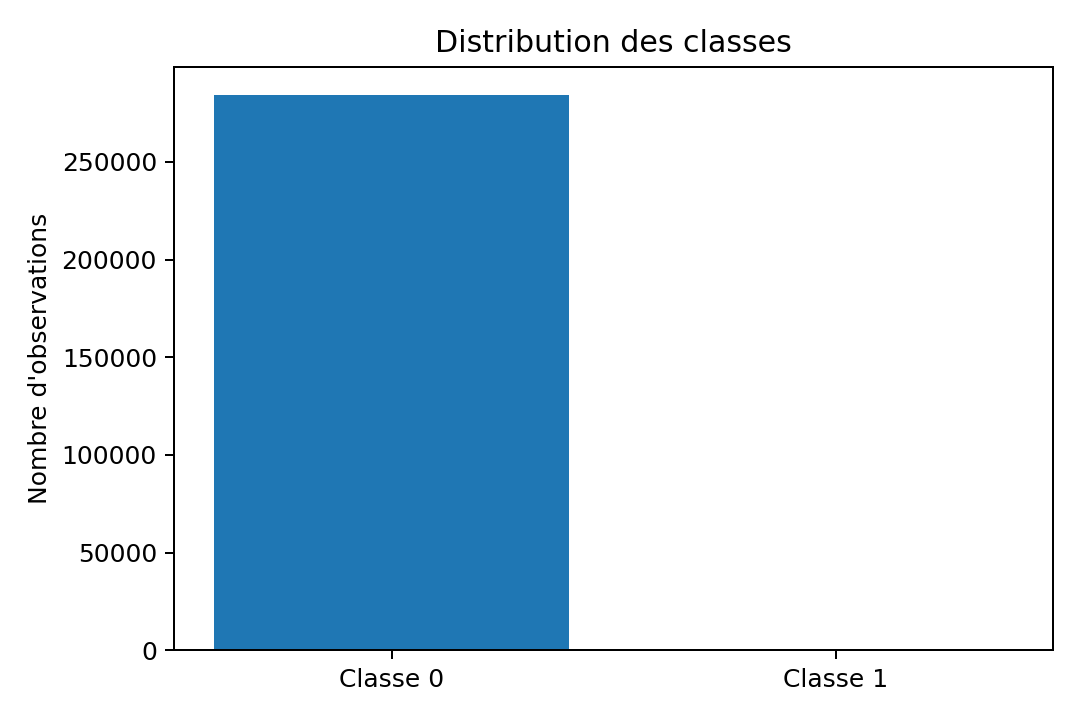

In [ ]:
# Figure : distribution des classes
from IPython.display import Image, display
display(Image(filename='outputs/class_distribution.png'))


Le graphique confirme visuellement le déséquilibre : la classe 0 domine presque entièrement la classe 1. C’est exactement pour cette raison qu’un modèle naïf peut avoir une très grande accuracy tout en ratant presque toutes les fraudes.


## 10.3 Matrice de corrélation et multicolinéarité

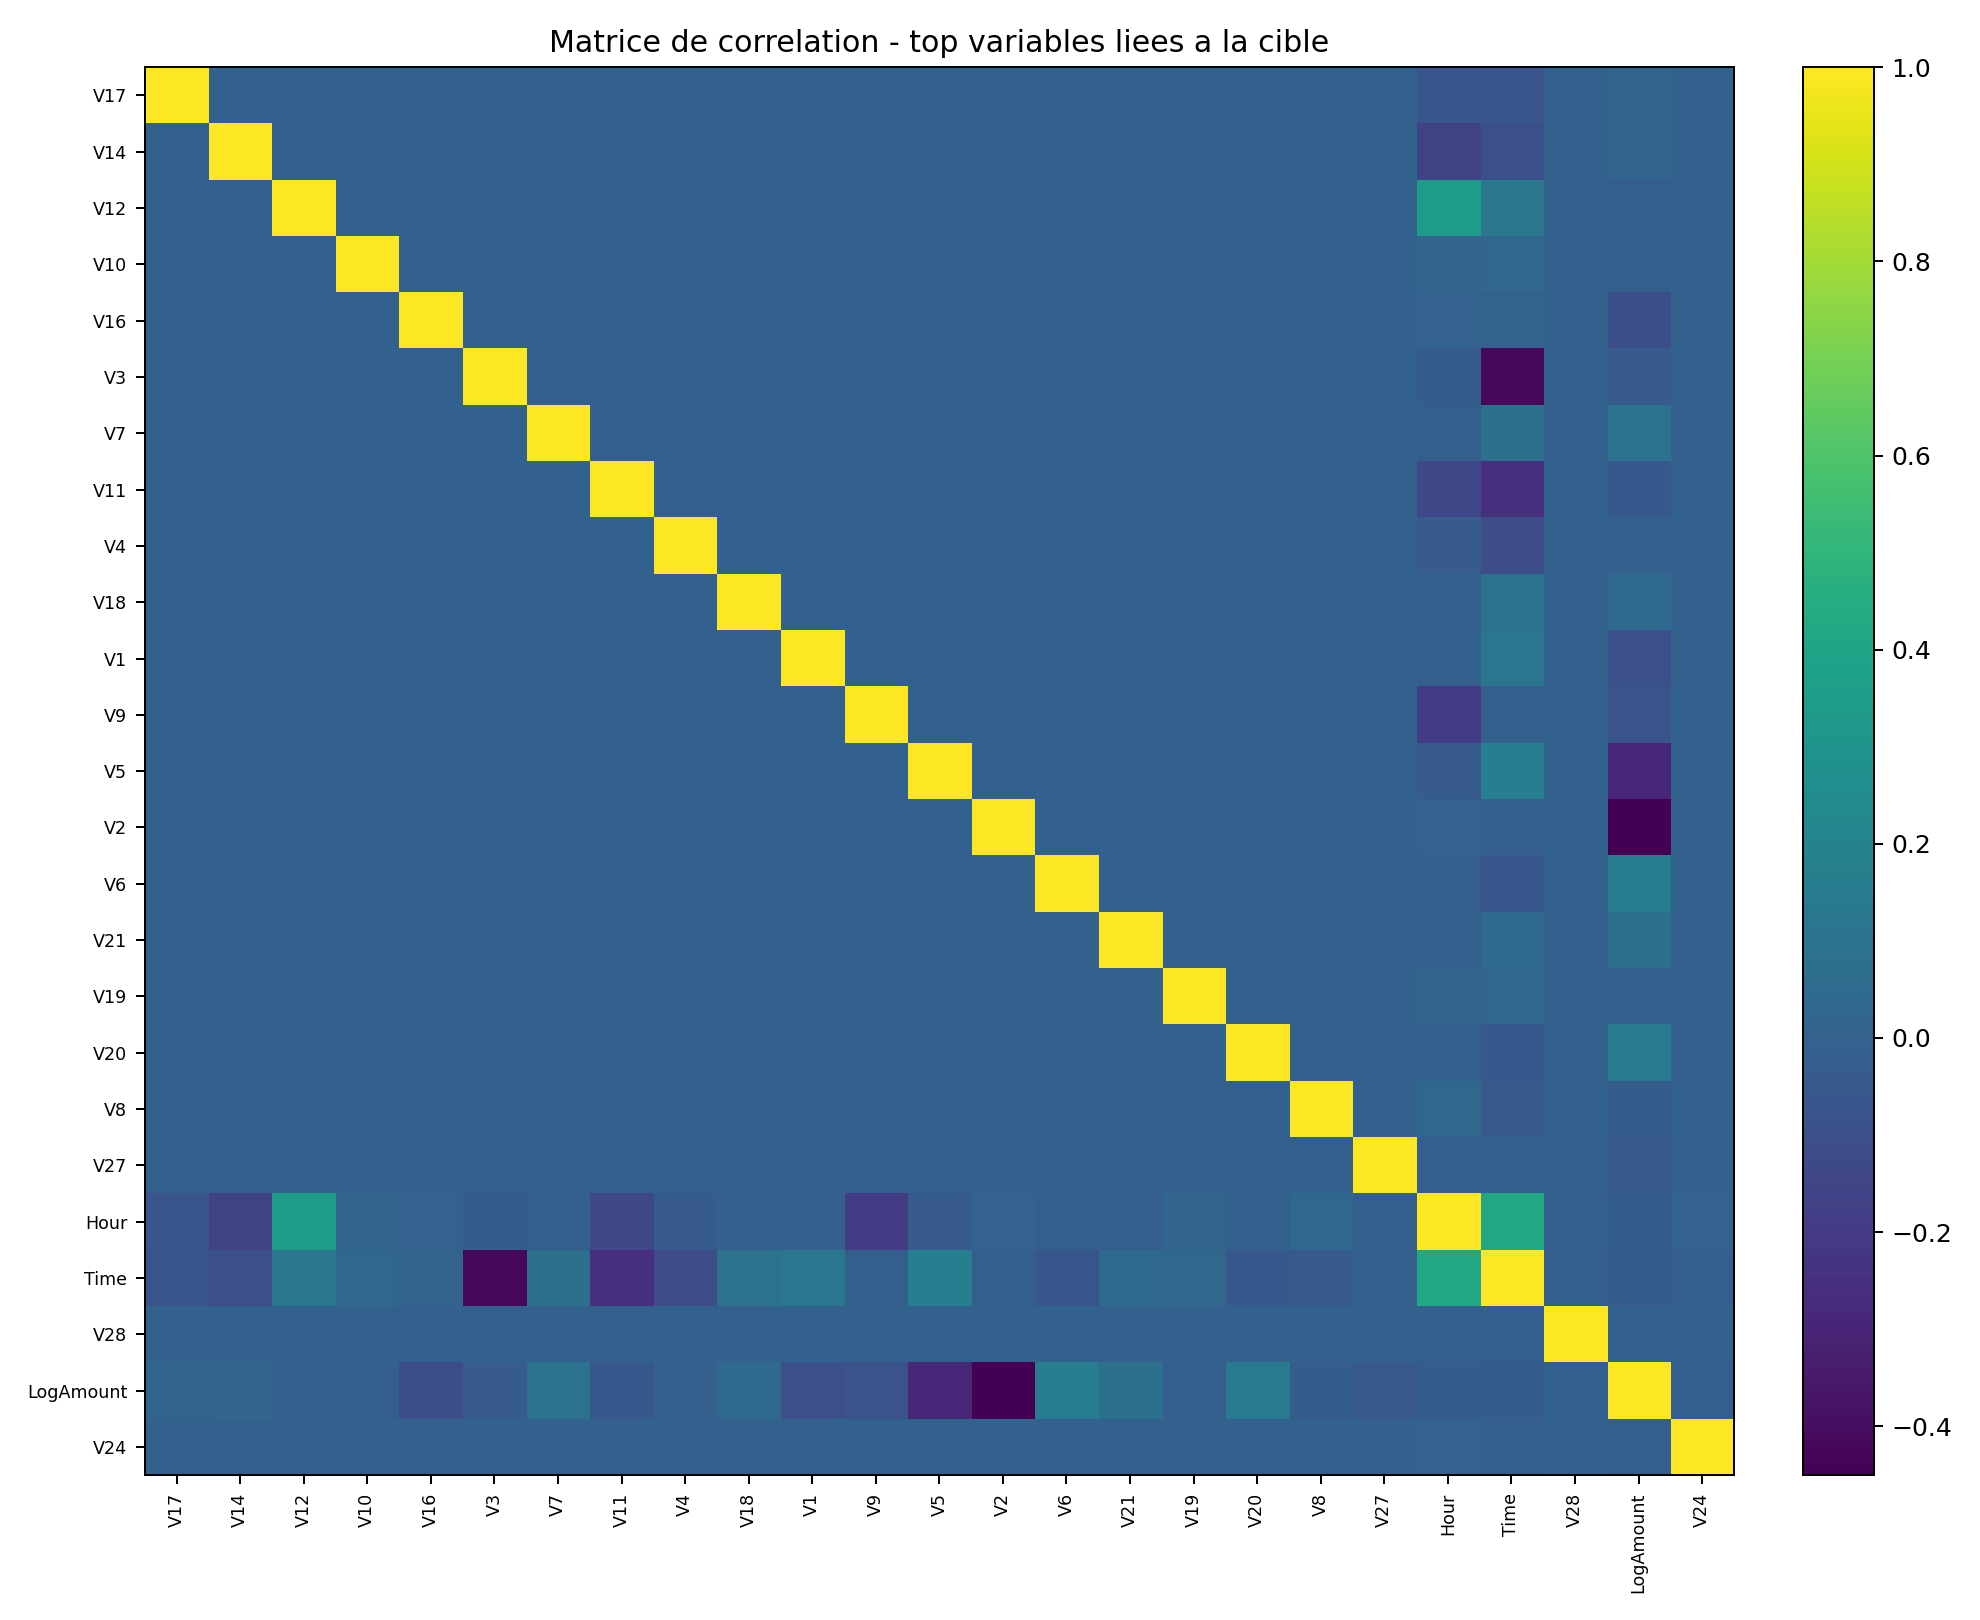

In [ ]:
# Figure : matrice de corrélation des variables les plus liées à la cible
display(Image(filename='outputs/correlation_matrix.png'))

In [ ]:
# Top VIF : variables avec la plus forte multicolinéarité
vif = pd.read_csv('outputs/vif.csv')
vif.head(15)

feature,vif
Time,8.567166
Hour,8.495961
LogAmount,4.749648
V3,1.273189
V2,1.207767
V5,1.181932
V12,1.091374
V11,1.045458
V1,1.043366
V6,1.043135



**Interprétation.** Les VIF les plus élevés concernent surtout `Time`, `Hour` et `LogAmount`, ce qui est logique car certaines variables sont dérivées les unes des autres. Les autres variables ont des VIF faibles, donc il n’y a pas de multicolinéarité critique pour la plupart des variables PCA.


## 10.4 Résumé final des métriques

In [ ]:
# Tableau final des métriques de tous les modèles
metrics = pd.read_csv('outputs/metrics_summary.csv')
metrics

model,threshold,f1_macro,auprc_average_precision,mcc,brier_loss,log_loss,business_cost
XGBoost - scale_pos_weight + Optuna,0.001205,0.615120,0.871590,0.346517,0.000431,0.002893,1062.0
XGBoost - custom asymmetric loss + Optuna,0.002613,0.622487,0.866267,0.358749,0.000426,0.002873,1019.0
Random Forest - class_weight,0.047895,0.631070,0.851161,0.374615,0.000590,0.005383,931.0
XGBoost calibrated - isotonic,0.001205,0.555865,0.836466,0.241476,0.000383,0.003146,1710.0
LR ElasticNet - SMOTE,0.865885,0.629564,0.722986,0.370359,0.025331,0.115546,982.0
LR ElasticNet - class_weight,0.019608,0.323909,0.709066,0.038348,0.024031,0.112992,30068.0
LR ElasticNet - ADASYN,0.988786,0.628059,0.644785,0.366103,0.065866,0.265553,1033.0



**Lecture du tableau.**

- `f1_macro` donne un poids équitable aux deux classes, même si la classe fraude est rare.
- `auprc_average_precision` mesure la qualité du classement des transactions suspectes.
- `mcc` est robuste dans les problèmes fortement déséquilibrés.
- `business_cost` applique le coût métier : `FP × 1 + FN × 50`.
- Le meilleur coût métier est obtenu par le **Random Forest class_weight** dans ce run.
- La meilleure AUPRC est obtenue par **XGBoost scale_pos_weight + Optuna**.


## 10.4 bis Matrices de confusion

Les figures ci-dessous montrent les **matrices de confusion sur le jeu de test** pour chaque modèle évalué.

**Rappel de lecture :**
- **TN (True Negatives)** : transactions normales correctement prédites comme normales ;
- **FP (False Positives)** : transactions normales signalées à tort comme fraudes ;
- **FN (False Negatives)** : fraudes non détectées ;
- **TP (True Positives)** : fraudes correctement détectées.

Dans un problème de fraude, les **FN** sont particulièrement importants, car ils correspondent à des fraudes ratées.  
C'est pour cela que le projet utilise aussi un **coût métier asymétrique** (`FP × 1 + FN × 50`).


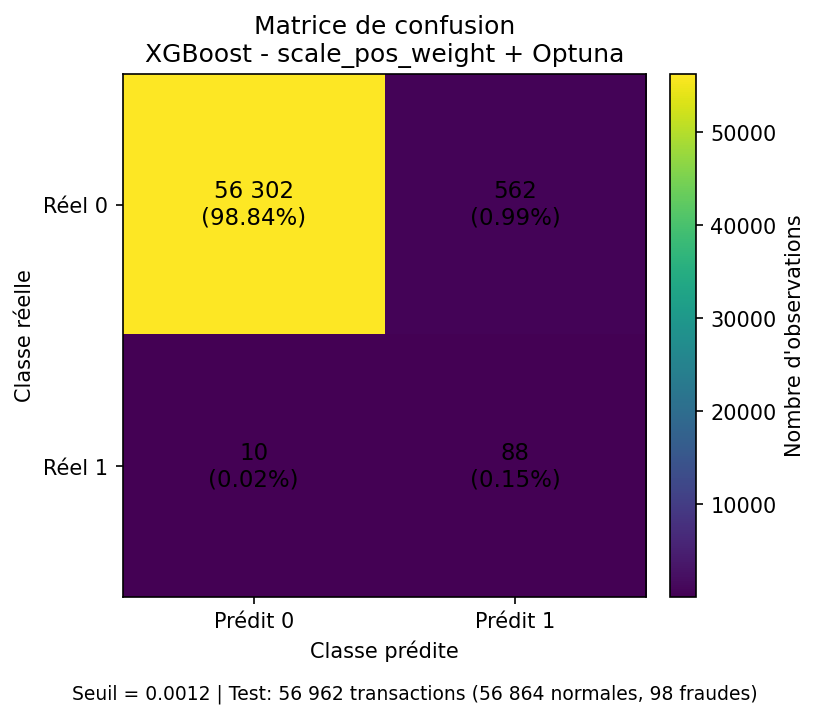

In [ ]:
# Affichage de la matrice de confusion : XGBoost - scale_pos_weight + Optuna
from IPython.display import Image, display
display(Image(filename='confusion_xgboost__scale_pos_weight_plus_optuna.png'))

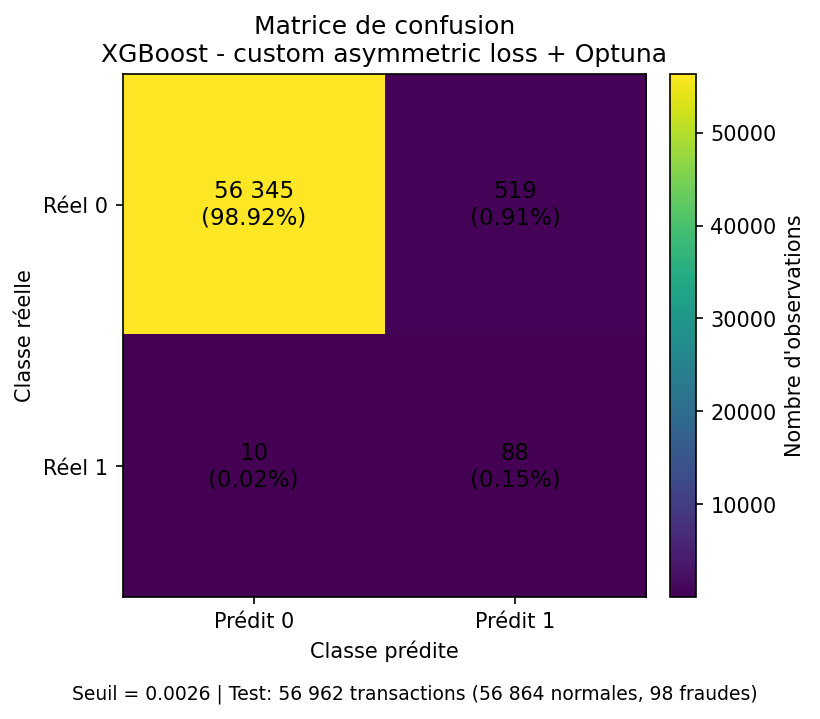

In [ ]:
# Affichage de la matrice de confusion : XGBoost - custom asymmetric loss + Optuna
from IPython.display import Image, display
display(Image(filename='confusion_xgboost__custom_asymmetric_loss_plus_optuna.png'))

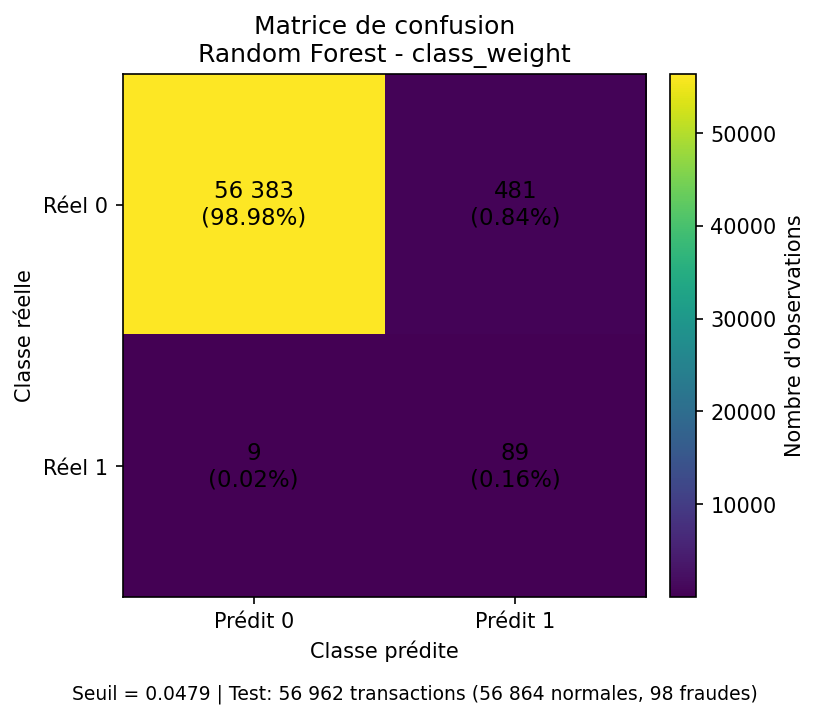

In [ ]:
# Affichage de la matrice de confusion : Random Forest - class_weight
from IPython.display import Image, display
display(Image(filename='confusion_random_forest__class_weight.png'))

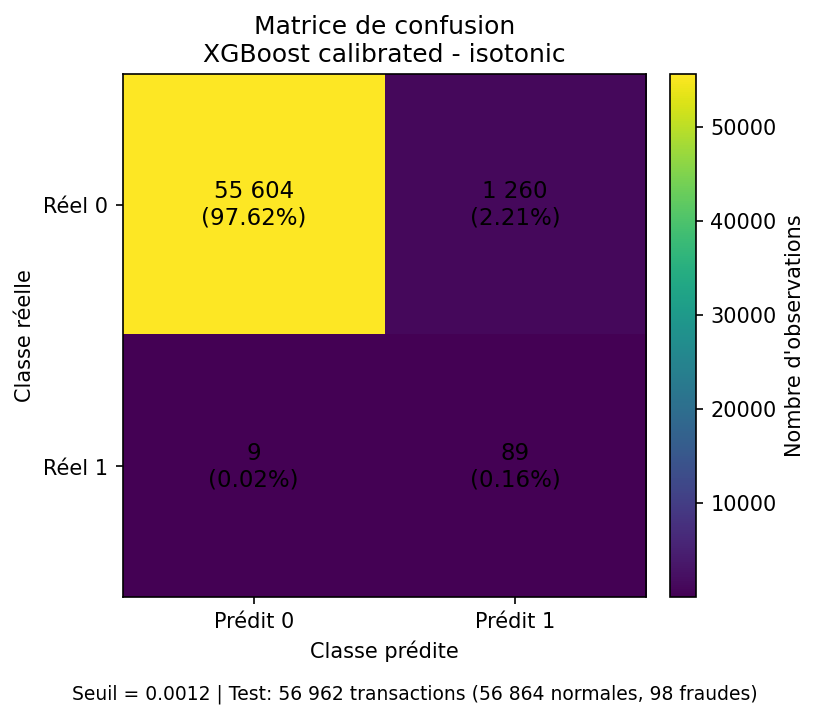

In [ ]:
# Affichage de la matrice de confusion : XGBoost calibrated - isotonic
from IPython.display import Image, display
display(Image(filename='confusion_xgboost_calibrated__isotonic.png'))

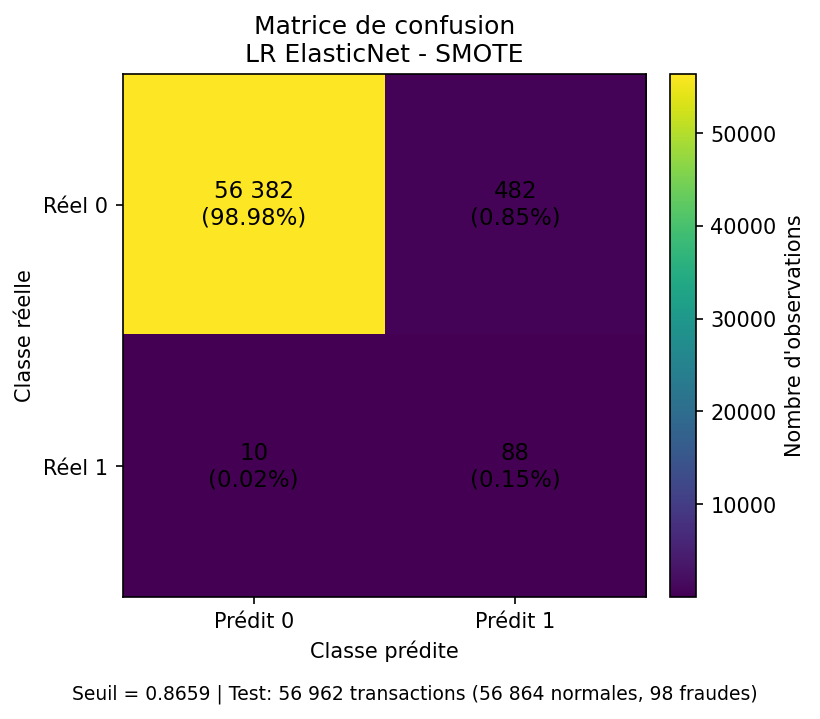

In [ ]:
# Affichage de la matrice de confusion : LR ElasticNet - SMOTE
from IPython.display import Image, display
display(Image(filename='confusion_lr_elasticnet__smote.png'))

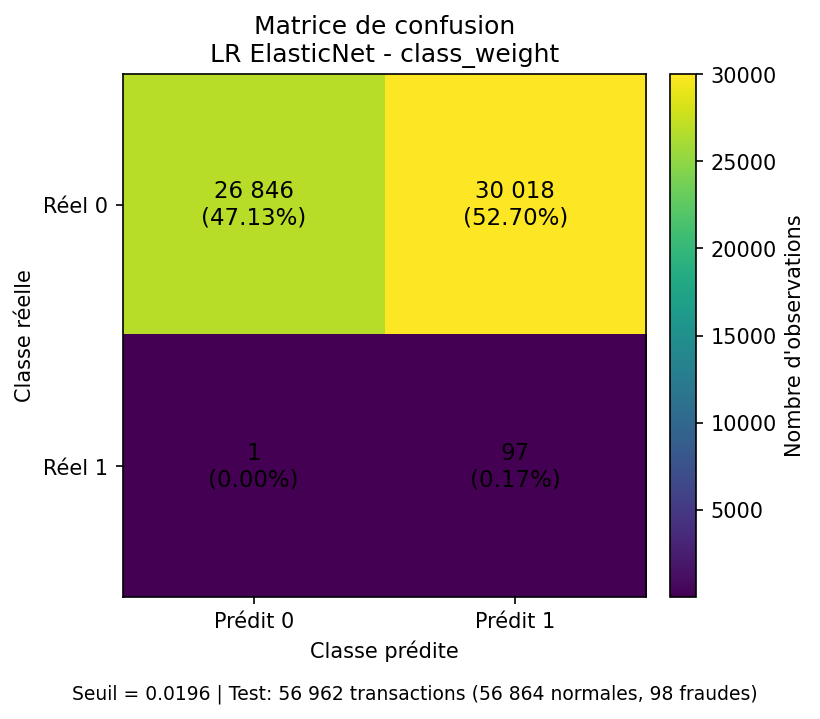

In [ ]:
# Affichage de la matrice de confusion : LR ElasticNet - class_weight
from IPython.display import Image, display
display(Image(filename='confusion_lr_elasticnet__class_weight.png'))

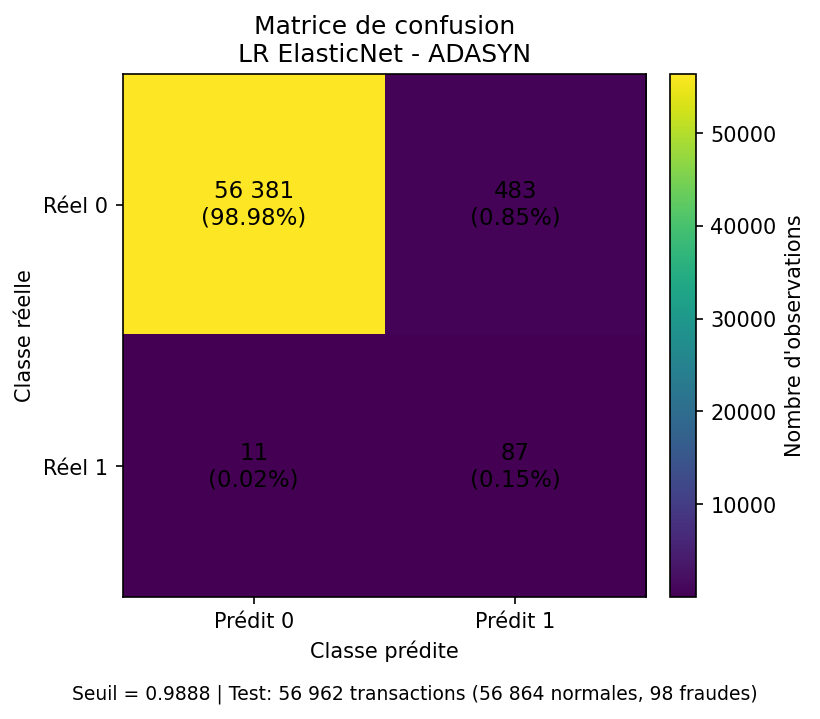

In [ ]:
# Affichage de la matrice de confusion : LR ElasticNet - ADASYN
from IPython.display import Image, display
display(Image(filename='confusion_lr_elasticnet__adasyn.png'))

## 10.5 Random Forest : proximité et outliers de prédiction

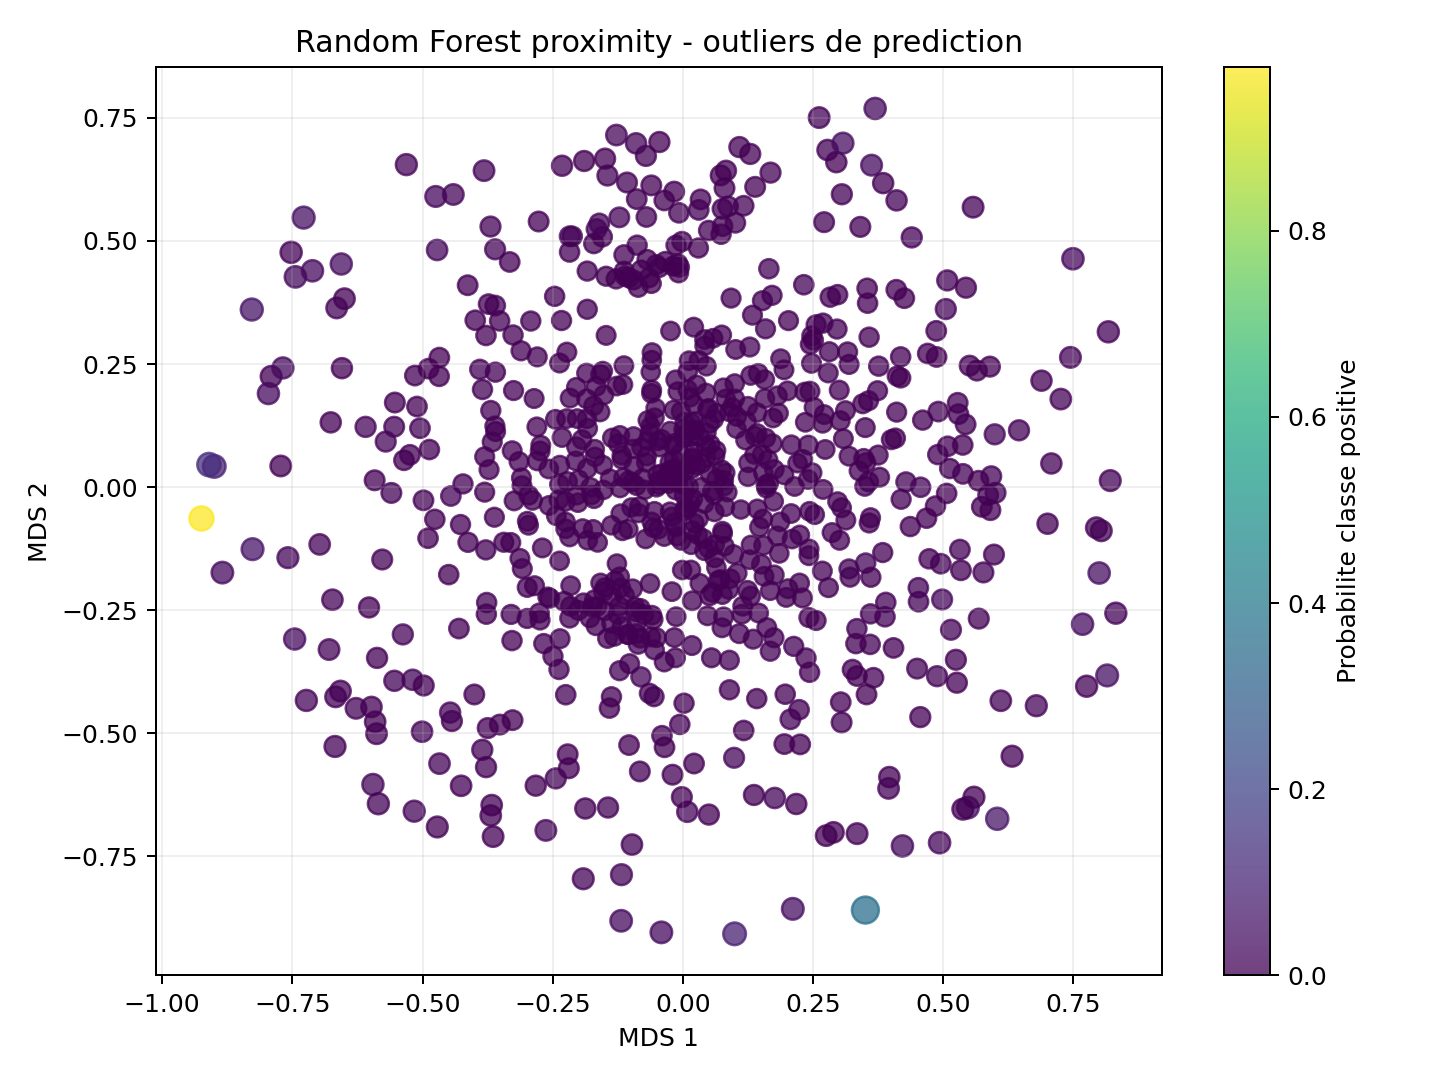

In [ ]:
# Figure : projection MDS des outliers selon la proximité Random Forest
display(Image(filename='outputs/rf_prediction_outliers_scatter.png'))

In [ ]:
# Top 10 des observations les plus difficiles pour Random Forest
outliers = pd.read_csv('outputs/rf_prediction_outliers.csv')
outliers.head(10)

sample_index_in_test,true_class,pred_class_threshold_05,proba_positive,uncertainty,lack_of_rf_proximity,prediction_error,outlier_score
17063,0,0,0.364914,0.729828,0.999064,0,0.714586
48129,0,1,0.975992,0.048016,1.000000,1,0.524008
9625,0,0,0.131346,0.262692,0.985013,0,0.476100
28260,0,0,0.090614,0.181227,0.979265,0,0.433356
38191,0,0,0.086202,0.172403,0.986178,0,0.431364
29192,0,0,0.060066,0.120132,0.975376,0,0.401447
48686,0,0,0.049637,0.099275,0.976182,0,0.391301
29573,0,0,0.045306,0.090612,0.981788,0,0.388932
28777,0,0,0.055843,0.111687,0.925096,0,0.379627
4669,0,0,0.039589,0.079178,0.970677,0,0.379326



**Analyse qualitative des outliers Random Forest.**

Les observations listées ci-dessus sont difficiles parce qu’elles combinent plusieurs signaux : une probabilité de fraude parfois élevée, une faible proximité avec les autres observations et parfois une erreur de prédiction. Par exemple, l’observation `48129` est une vraie classe 0 mais elle reçoit une probabilité positive très élevée et est prédite comme fraude à seuil 0,5. C’est donc un **faux positif** : la transaction est normale, mais son profil ressemble fortement à des cas frauduleux selon les arbres.

La colonne `lack_of_rf_proximity` proche de 1 indique que l’observation tombe rarement dans les mêmes feuilles que les autres points. Cela signifie que le modèle la considère comme atypique. Dans ce cas, le modèle hésite ou échoue parce que la transaction se trouve dans une zone peu dense de l’espace appris par le Random Forest, avec des caractéristiques qui ne ressemblent pas clairement à la majorité des transactions normales.


## 10.6 Convergence Optuna

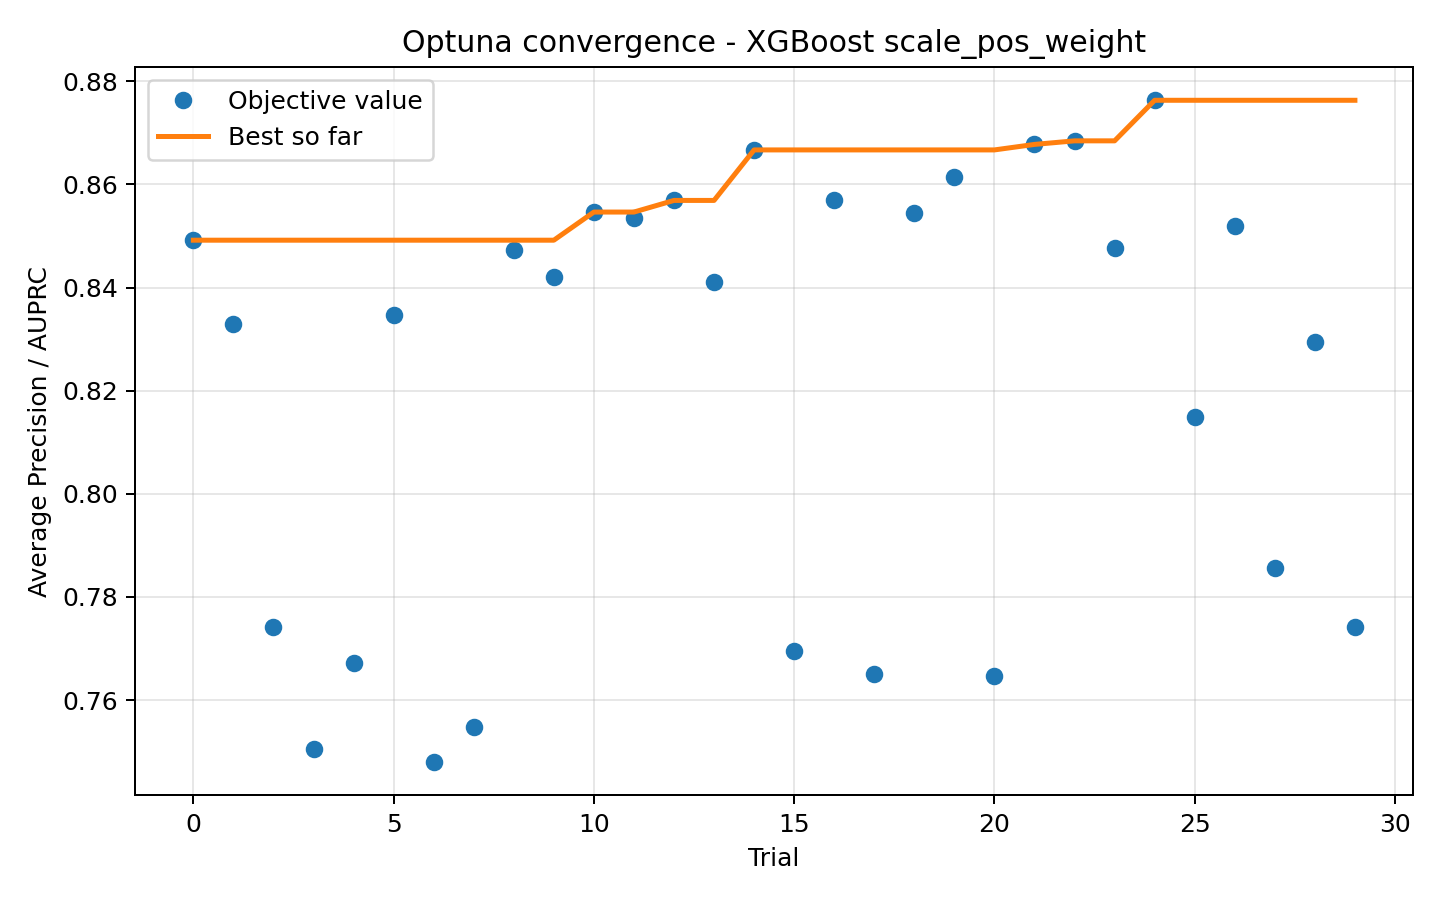

In [ ]:
# Convergence Optuna : XGBoost avec scale_pos_weight
display(Image(filename='outputs/optuna_history_xgb_scale_pos_weight.png'))

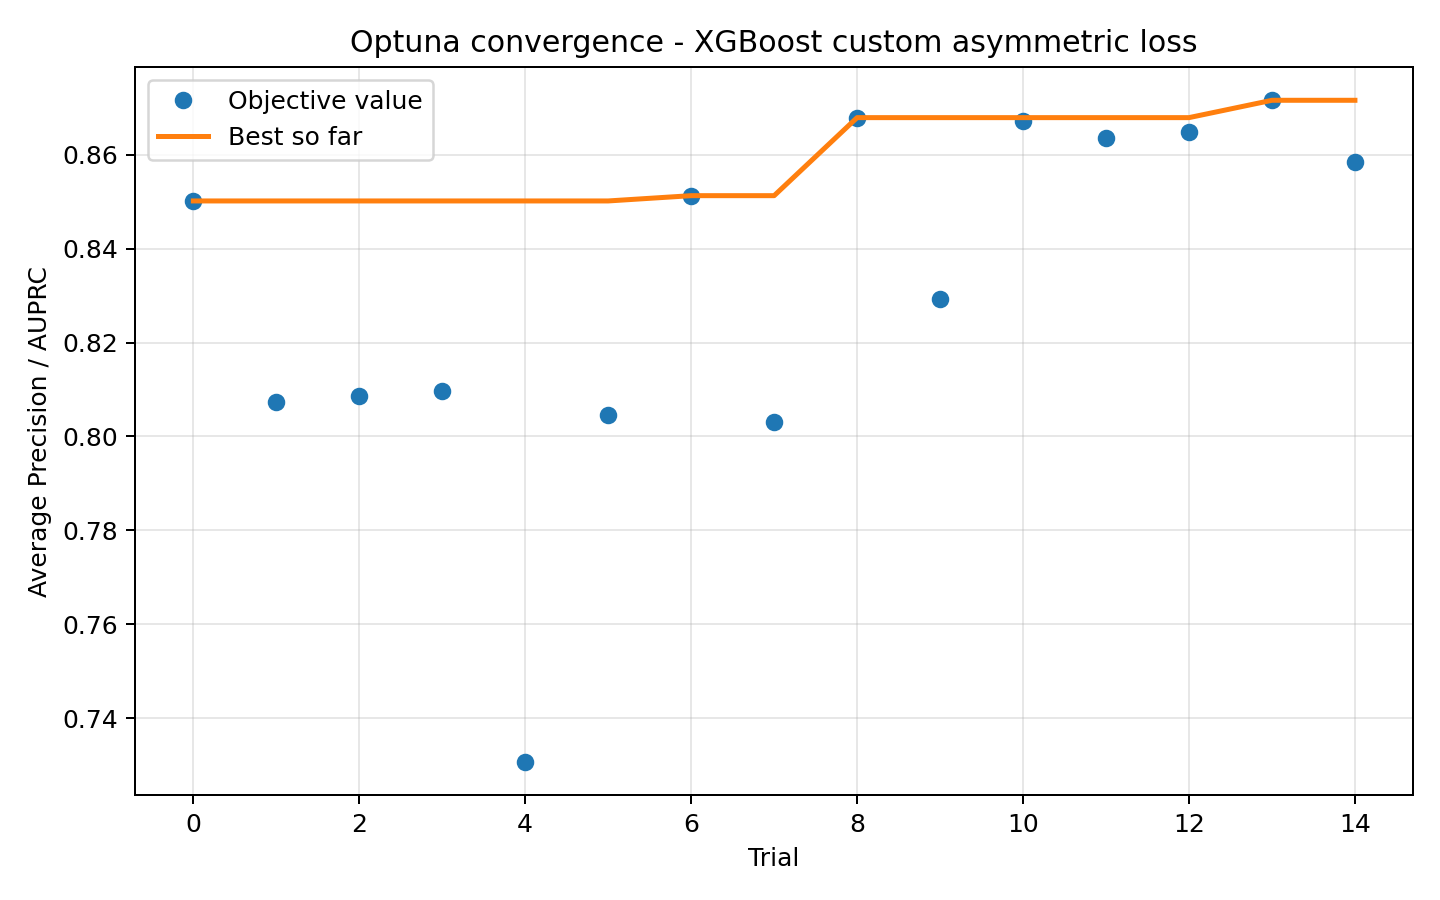

In [ ]:
# Convergence Optuna : XGBoost avec custom asymmetric loss
display(Image(filename='outputs/optuna_history_xgb_custom_loss.png'))


**Interprétation.** La ligne `Best so far` augmente par paliers. Cela montre qu’Optuna explore plusieurs combinaisons d’hyperparamètres et conserve progressivement les meilleures. Les points plus bas correspondent à des essais moins performants, mais ils sont utiles car ils permettent à l’algorithme d’apprendre quelles zones de recherche sont moins intéressantes.


## 10.7 Meilleurs hyperparamètres XGBoost

In [ ]:
# Meilleurs paramètres XGBoost avec scale_pos_weight
with open('outputs/best_params_xgb_scale_pos_weight.json', 'r', encoding='utf-8') as f:
    best_params_spw = json.load(f)
print(json.dumps(best_params_spw, indent=2, ensure_ascii=False))

{
  "max_depth": 10,
  "learning_rate": 0.1252125943833924,
  "n_estimators": 519,
  "min_child_weight": 3.986511459554404,
  "subsample": 0.7163801406750037,
  "colsample_bytree": 0.7833121885702731,
  "reg_alpha": 0.0006131191474419425,
  "reg_lambda": 0.008433579358582122,
  "gamma": 0.8853156768320467,
  "scale_pos_weight": 1946.822282410901
}


In [ ]:
# Meilleurs paramètres XGBoost avec fonction de perte asymétrique
with open('outputs/best_params_xgb_custom_loss.json', 'r', encoding='utf-8') as f:
    best_params_custom = json.load(f)
print(json.dumps(best_params_custom, indent=2, ensure_ascii=False))

{
  "params": {
    "max_depth": 3,
    "eta": 0.08888628409181555,
    "min_child_weight": 1.6986483836707045,
    "subsample": 0.7737849726003561,
    "colsample_bytree": 0.9142810499193087,
    "lambda": 0.0013026066818627973,
    "alpha": 7.295272712759666e-05,
    "gamma": 1.5135202009605735,
    "tree_method": "hist",
    "seed": 42,
    "verbosity": 0
  },
  "num_boost_round": 767
}



**Justification rapide.** `max_depth`, `min_child_weight`, `gamma`, `reg_alpha` et `reg_lambda` contrôlent la complexité du modèle. `subsample` et `colsample_bytree` ajoutent de la randomisation pour réduire l’overfitting. `learning_rate` et `n_estimators` contrôlent la vitesse et la durée de l’apprentissage. Enfin, `scale_pos_weight` corrige le déséquilibre en donnant plus d’importance à la classe fraude.


## 10.8 Courbes Precision-Recall

### LR ElasticNet - class_weight

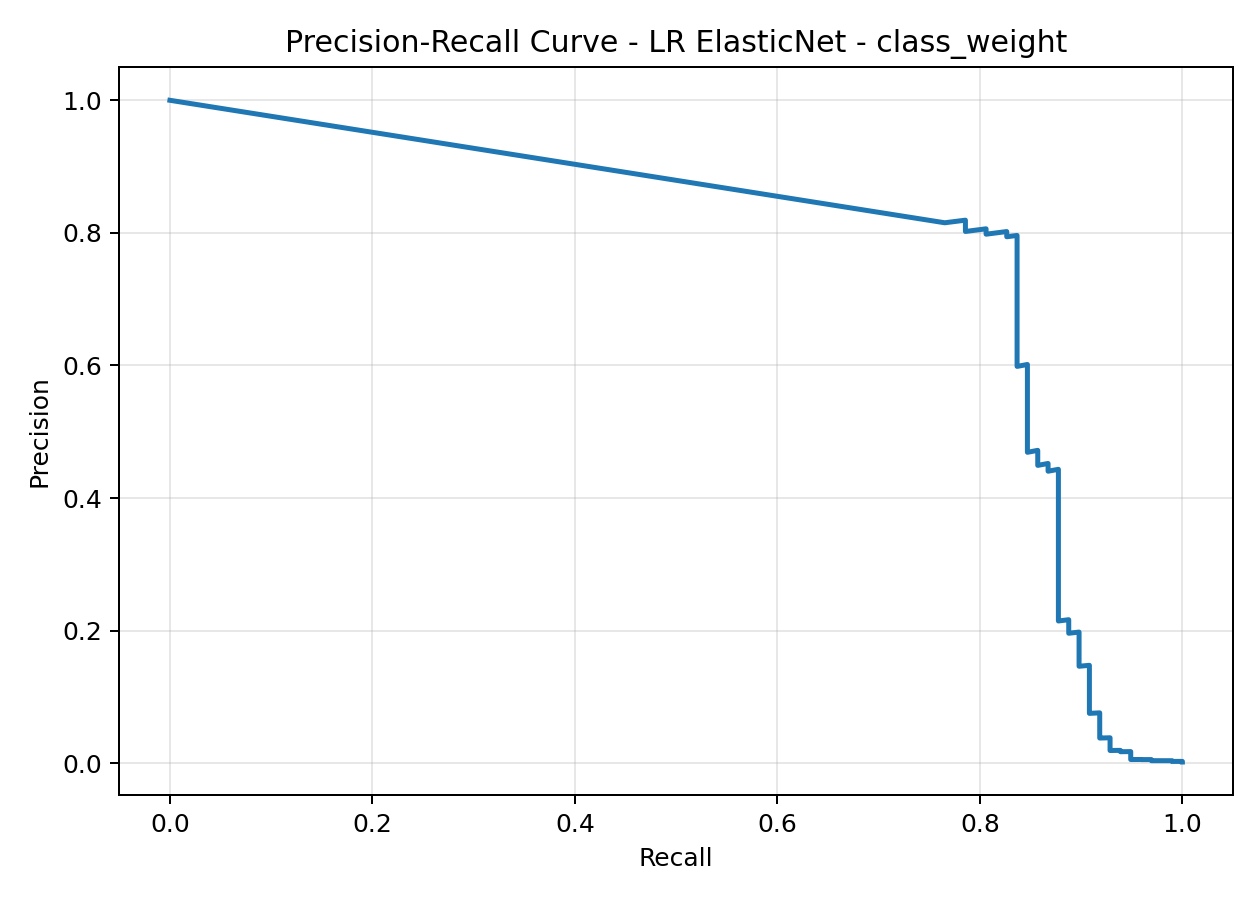

In [ ]:
# Courbe Precision-Recall : LR ElasticNet - class_weight
display(Image(filename='outputs/pr_curve_lr_elasticnet___class_weight.png'))

### LR ElasticNet - SMOTE

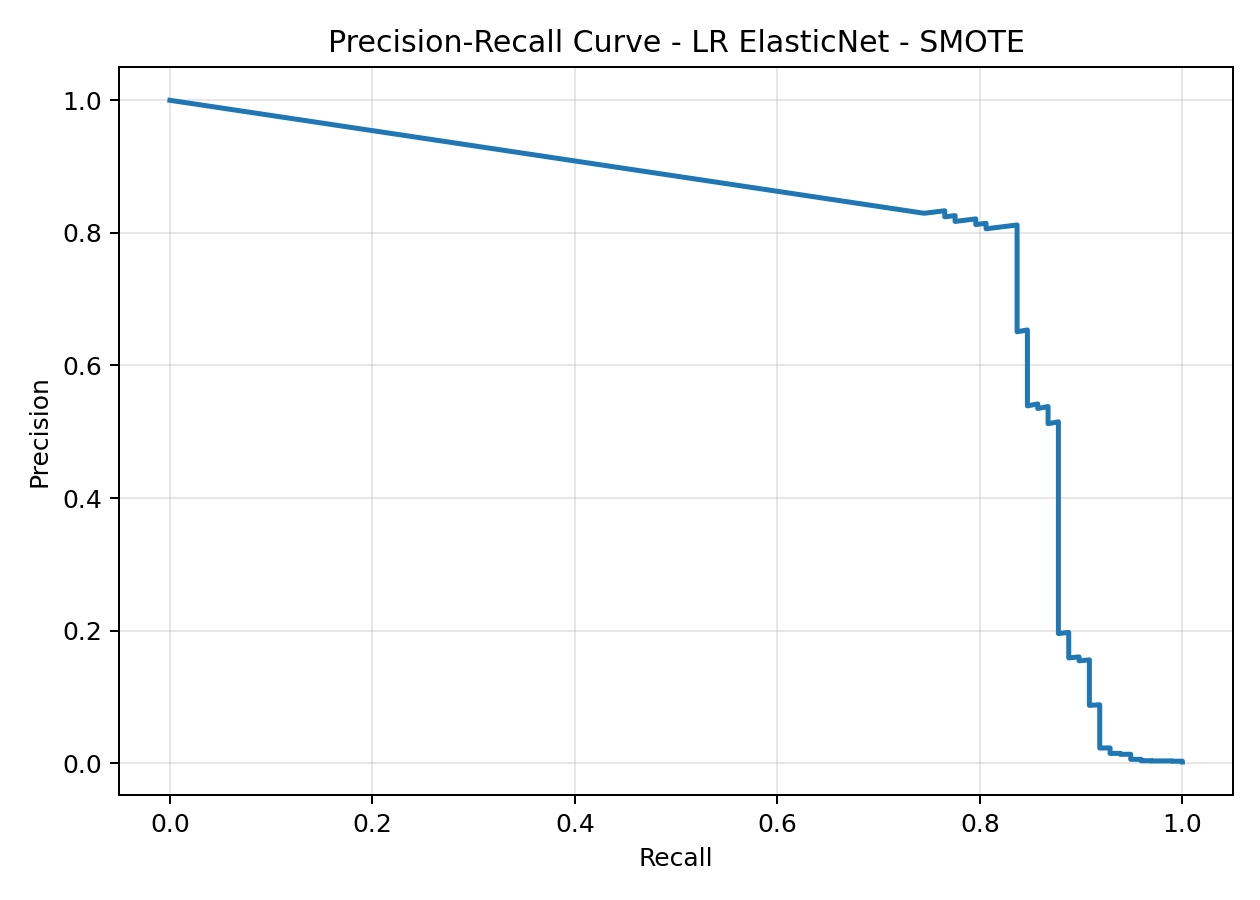

In [ ]:
# Courbe Precision-Recall : LR ElasticNet - SMOTE
display(Image(filename='outputs/pr_curve_lr_elasticnet___smote.png'))

### LR ElasticNet - ADASYN

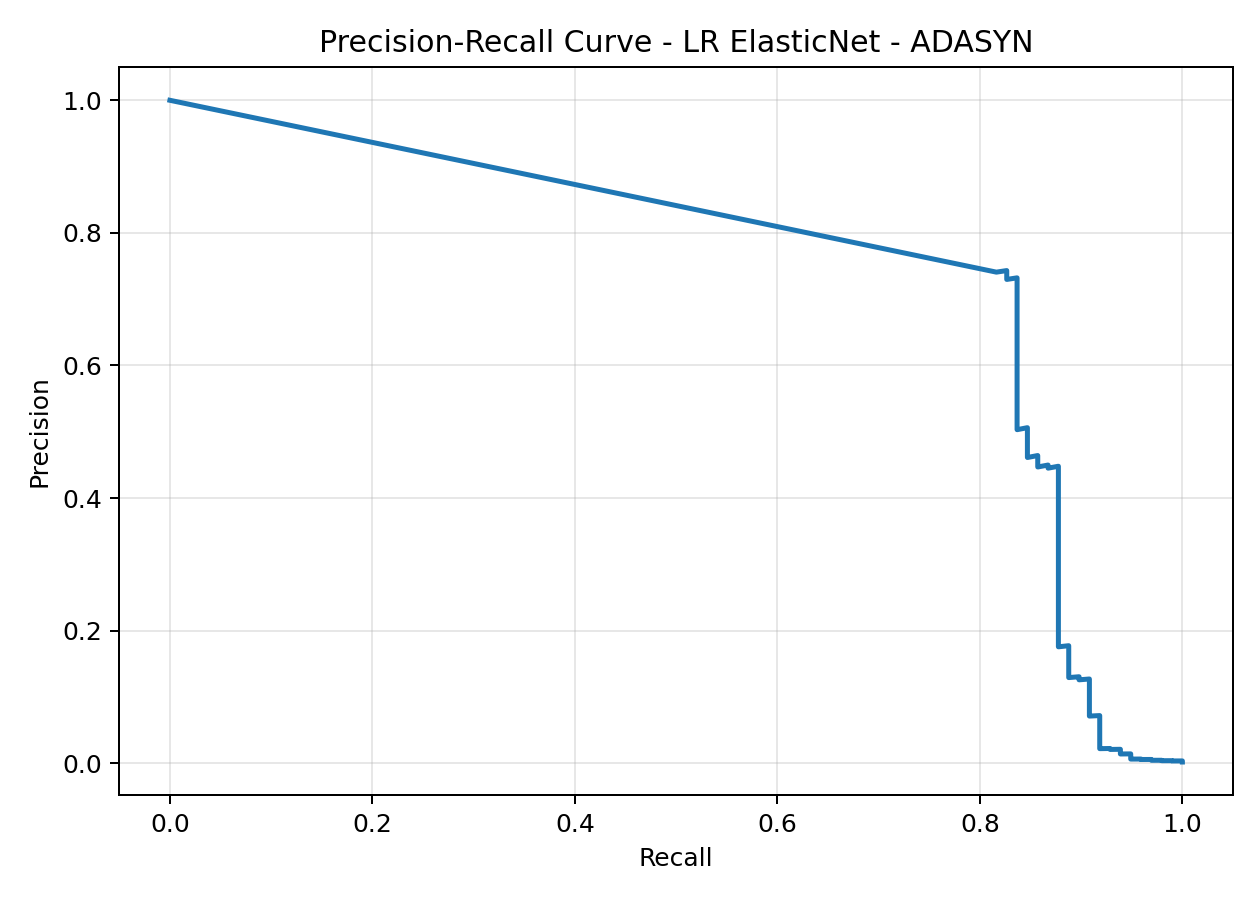

In [ ]:
# Courbe Precision-Recall : LR ElasticNet - ADASYN
display(Image(filename='outputs/pr_curve_lr_elasticnet___adasyn.png'))

### Random Forest - class_weight

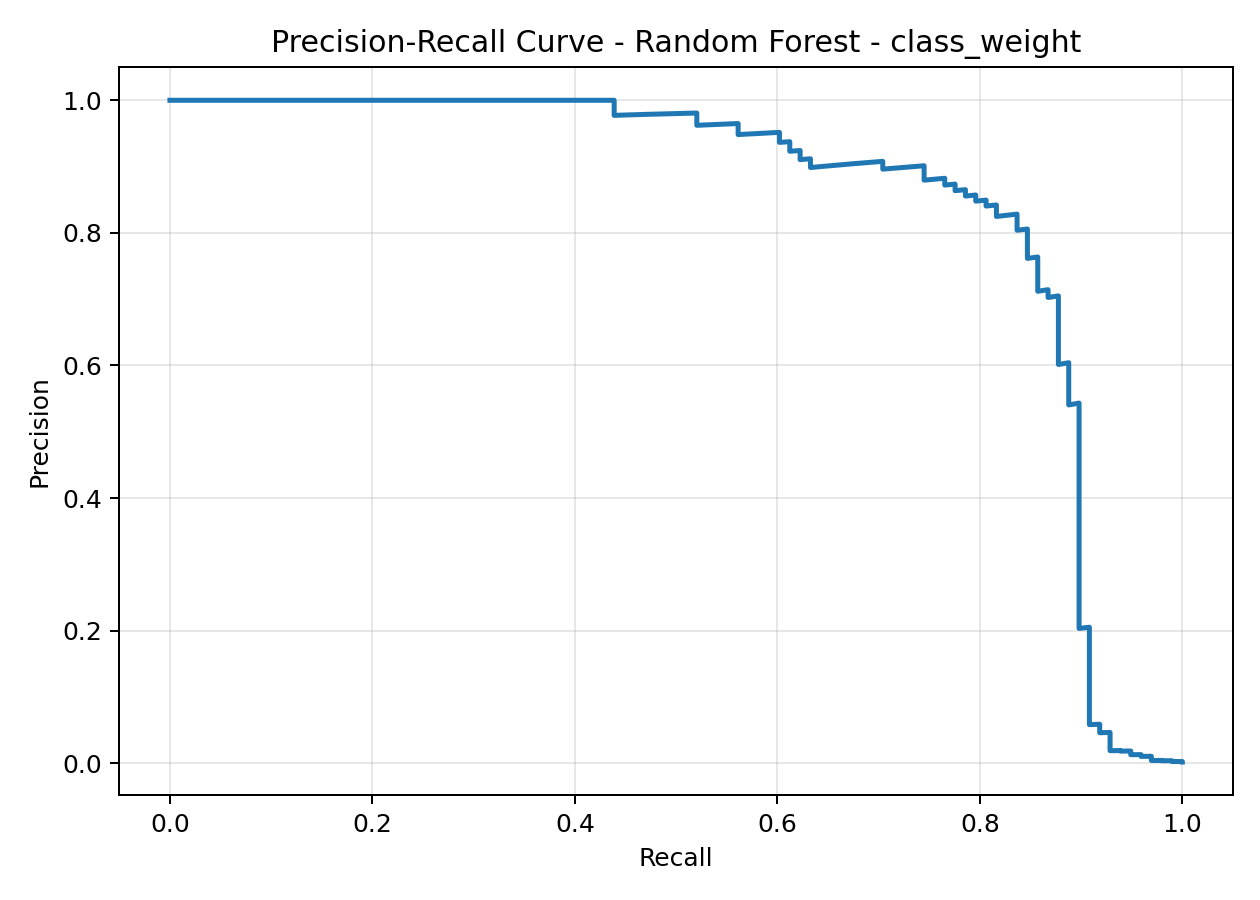

In [ ]:
# Courbe Precision-Recall : Random Forest - class_weight
display(Image(filename='outputs/pr_curve_random_forest___class_weight.png'))

### XGBoost - scale_pos_weight + Optuna

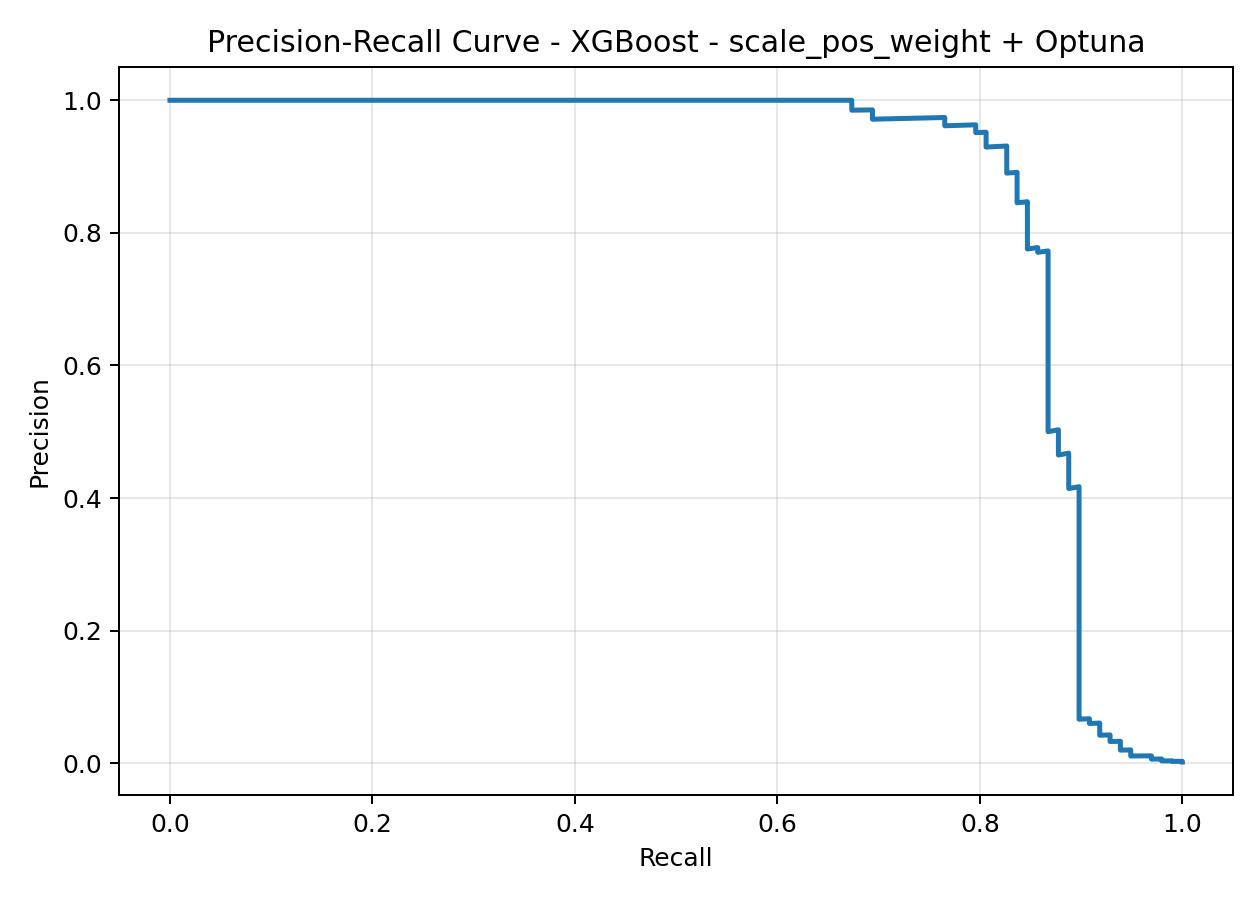

In [ ]:
# Courbe Precision-Recall : XGBoost - scale_pos_weight + Optuna
display(Image(filename='outputs/pr_curve_xgboost___scale_pos_weight_+_optuna.png'))

### XGBoost - custom asymmetric loss + Optuna

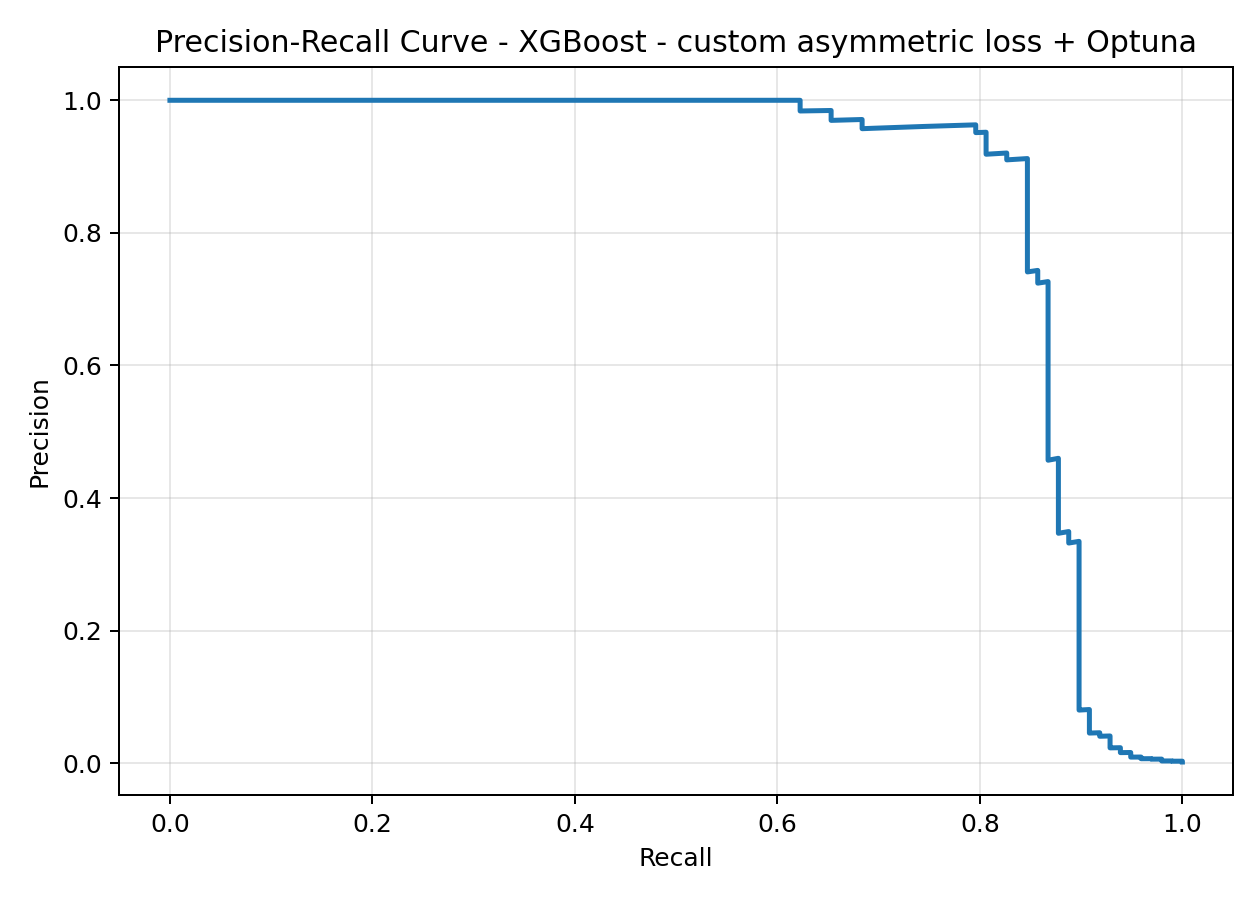

In [ ]:
# Courbe Precision-Recall : XGBoost - custom asymmetric loss + Optuna
display(Image(filename='outputs/pr_curve_xgboost___custom_asymmetric_loss_+_optuna.png'))

### XGBoost calibré - isotonic

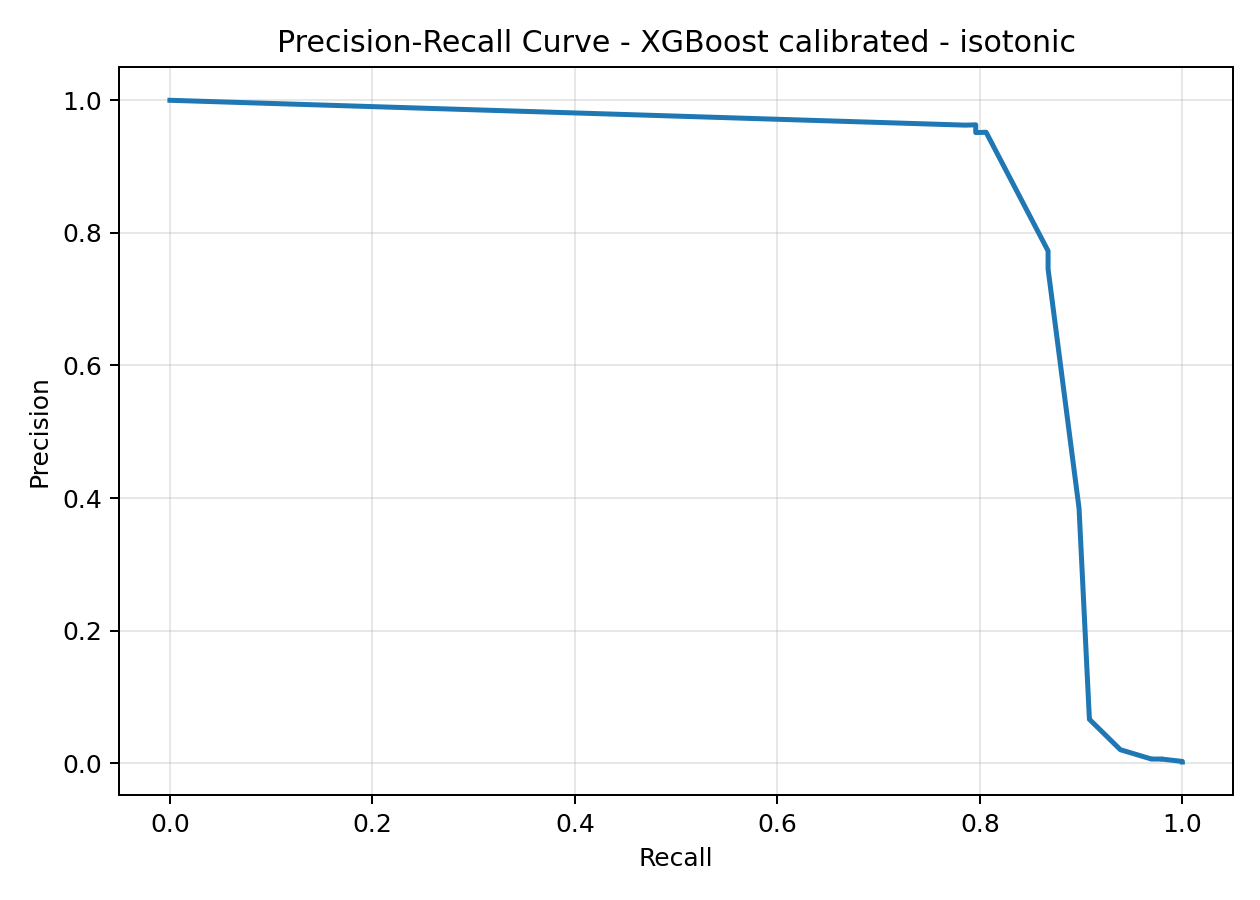

In [ ]:
# Courbe Precision-Recall : XGBoost calibré - isotonic
display(Image(filename='outputs/pr_curve_xgboost_calibrated___isotonic.png'))


**Interprétation.** Les courbes Precision-Recall sont plus pertinentes que les courbes ROC dans ce projet, car la classe positive est très rare. Les courbes de XGBoost et Random Forest restent plus hautes sur une partie importante du rappel, ce qui confirme leur meilleure capacité à classer les transactions frauduleuses avant les transactions normales.


## 10.9 Calibration des probabilités

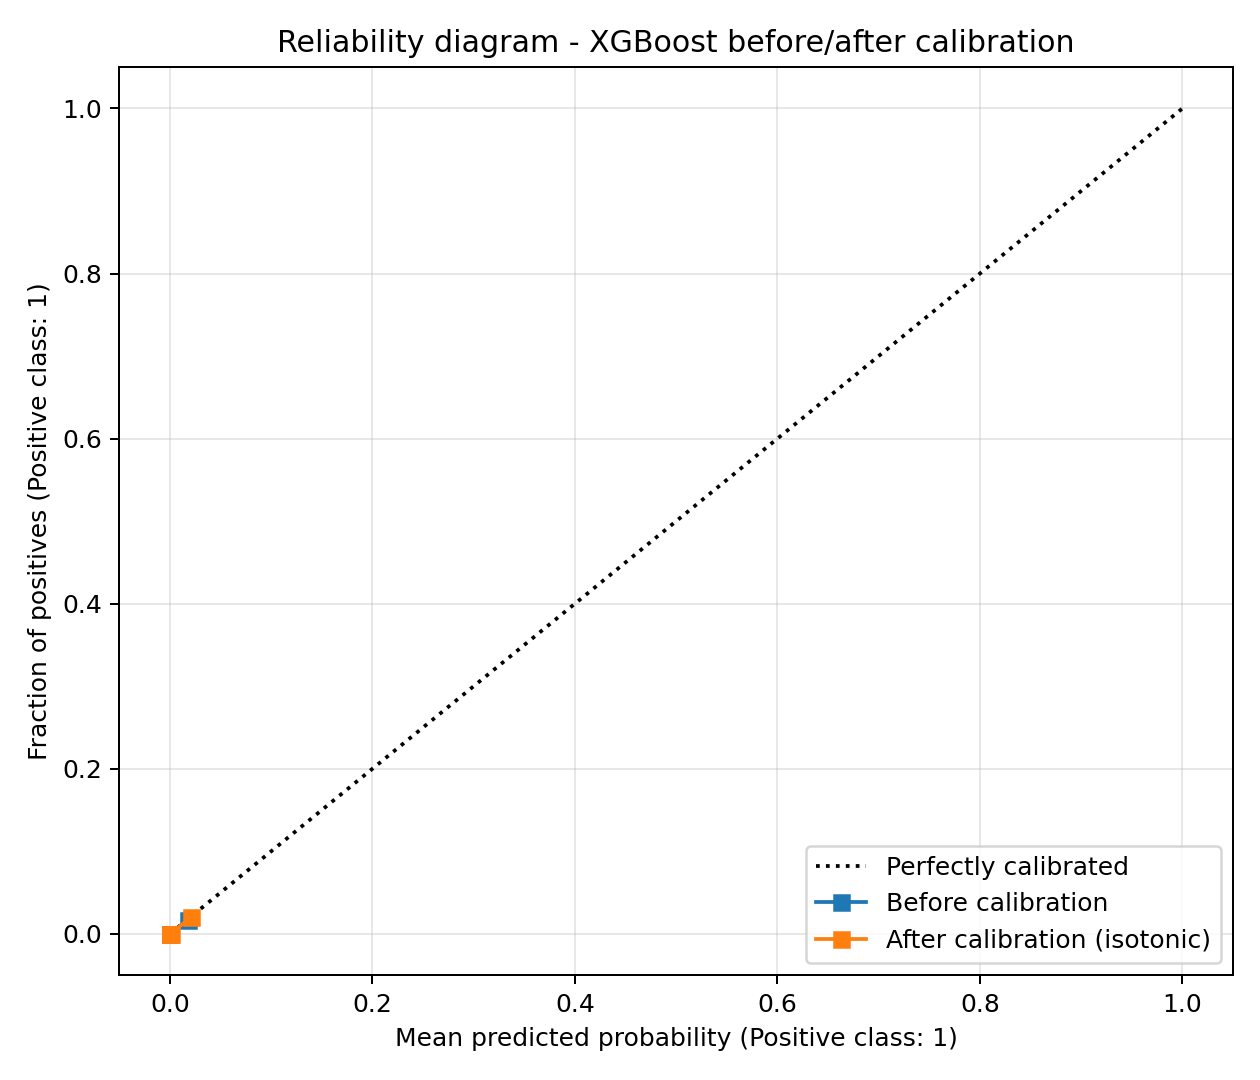

In [ ]:
# Diagramme de fiabilité : avant/après calibration isotonic
display(Image(filename='outputs/reliability_diagram_xgb_before_after.png'))


**Interprétation.** Le diagramme de fiabilité compare les probabilités prédites avec la fréquence réelle de la classe positive. La calibration isotonic vise à rendre les probabilités plus fiables. Dans ce projet, le modèle calibré obtient le meilleur `Brier Loss`, ce qui montre une amélioration de la qualité probabiliste, même si le coût métier n’est pas le meilleur.



## 10.10 Conclusion intégrée au notebook

Le notebook contient maintenant non seulement le code, mais aussi les sorties finales : tableaux, métriques, figures EDA, courbes Precision-Recall, convergence Optuna, calibration et analyse des outliers Random Forest.

La conclusion principale est la suivante :

- le dataset est extrêmement déséquilibré ;
- l’accuracy ne doit pas être utilisée comme métrique principale ;
- Random Forest donne le meilleur coût métier dans ce run ;
- XGBoost donne la meilleure AUPRC ;
- la calibration isotonic améliore la qualité des probabilités ;
- l’analyse de proximité Random Forest permet d’expliquer les cas où le modèle hésite ou se trompe.
